# 4. EfficientDet 기반 제조영상 분석 최적화

**박서준 | 한양대학교 ERICA 인공지능학과**

EfficientDet-D0로 이미지·영상 추론, 데이터 검증, 2단계 미세조정과 최종 평가를 진행했습니다. 실험 조건과 실제 수치, 한계 및 KPT는 12절에 정리했습니다.

- 실행일: 2026-09-27 / RUN_ID: `20260927_083522`
- 학습: head-only 10 epoch + full 30 epoch, T4, batch 16
- 최종 test: mAP50 **0.0889**, mAP50–95 **0.0576** (성능 한계도 그대로 기록했습니다.)
- 원본 Colab: https://colab.research.google.com/drive/1IEaZ030mPBNJzez6RZvUkmAZe-A2lrhP
- 데이터: https://www.kaggle.com/datasets/pkdarabi/vehicle-detection-image-dataset

출력과 그림을 포함한 실행 기록입니다. 환경·버전·seed에 따라 재실행 수치는 달라질 수 있습니다.

## 실행 메모

- 이 실행본의 학습·평가 스위치는 실제 수행 조건인 `True`로 남겨 두었습니다. **전체 실행을 다시 누르면 GPU 학습과 새로운 test 평가가 실행될 수 있습니다.** 결과 확인만 할 때는 저장된 출력을 읽어 주세요.
- 현재 RUN_ID의 완료된 학습은 summary를 재사용하며, test 완료 marker는 반복 평가를 막습니다. 공통 설정을 다시 실행하면 새 RUN_ID가 생성되므로 기존 기록과 구분해야 합니다.
- 원본 데이터는 바꾸지 않고 `/content`의 작업 복사본만 변환했습니다.
- validation으로 모델과 confidence를 정한 다음 test를 한 번 평가했습니다.
- 가중치·로그·CSV·이미지·처리 영상은 `MyDrive/EfficientDet_results/20260927_083522`에 보관했습니다.

실행 흐름은 다음과 같습니다.

```text
사전학습 이미지·영상 추론
          ↓
데이터 검증 → 원본 보존 작업본 생성 → train 통계·anchor 설정
          ↓
head 10 epoch → full 30 epoch → validation loss로 checkpoint 선택
          ↓
validation AP·confidence 비교 → 조건 고정 → test 1회 평가
          ↓
결과 저장·한계 분석·KPT
```

## 0. 공통 설정

Kaggle 데이터: https://www.kaggle.com/datasets/pkdarabi/vehicle-detection-image-dataset

데이터는 Drive에 두거나 Kaggle에서 받아 둡니다. `DATASET_HINT`, `VIDEO_PATH`, 학습·평가 스위치, 기존 checkpoint 경로는 각 단계 셀에서 설정합니다. 인증 토큰이나 권한은 변경하지 않습니다.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter, deque
import os, sys, json, math, shutil, hashlib, subprocess, unicodedata, zipfile, time, threading

SEED = 42
SAVE_TO_DRIVE = True
# checkpoint는 Colab 세션 종료 시 /content와 함께 사라지므로 기본 보관을 권장합니다.
# Drive에는 stage(attempt)별 best checkpoint 1개만 두고, 내용이 바뀐 경우에만 교체합니다.
SAVE_CHECKPOINT_TO_DRIVE = True

MAX_DRIVE_SEARCH_DEPTH = 5
MAX_VIDEO_FRAMES = 300
VAL_COMPARE_LIMIT = 100
THRESHOLDS = (0.25, 0.50, 0.75)
IOU_MATCH = 0.50

# 같은 커널에서 이 셀을 다시 실행해도 RUN_ID는 유지합니다.
if 'RUN_ID' not in globals():
    RUN_ID = datetime.now(timezone.utc).astimezone().strftime('%Y%m%d_%H%M%S')
CONTENT = Path('/content')
REPO_DIR = CONTENT / 'Yet-Another-EfficientDet-Pytorch'
LOCAL_RUN_DIR = CONTENT / 'effdet_runs' / RUN_ID
LOCAL_RUN_DIR.mkdir(parents=True, exist_ok=True)

def sha256_file(path, chunk=1024*1024):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda: f.read(chunk), b''):
            h.update(block)
    return h.hexdigest()

def write_json_atomic(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(f'.{path.name}.tmp-{os.getpid()}')
    tmp.write_text(json.dumps(obj, indent=2, ensure_ascii=False, default=str), encoding='utf-8')
    os.replace(tmp, path)
    return path

_SYNC_CACHE = {}
def sync_file(src, dst):
    """멱등·원자적 복사: 내용이 같으면 건너뛰고, 바뀐 경우만 임시 파일에 쓴 뒤 os.replace로 교체."""
    src, dst = Path(src), Path(dst)
    if not src.is_file():
        return 'missing'
    if dst.exists() and src.resolve() == dst.resolve():
        return 'same_path'
    st = src.stat()
    sig = (st.st_size, st.st_mtime_ns)
    if _SYNC_CACHE.get(str(dst)) == sig and dst.exists():
        return 'unchanged'
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size == st.st_size and sha256_file(dst) == sha256_file(src):
        _SYNC_CACHE[str(dst)] = sig
        return 'unchanged'
    tmp = dst.with_name(f'.{dst.name}.partial-{os.getpid()}')
    try:
        shutil.copy2(src, tmp)
        os.replace(tmp, dst)
    finally:
        if tmp.exists():
            tmp.unlink()
    _SYNC_CACHE[str(dst)] = sig
    return 'copied'

print('RUN_ID:', RUN_ID)
print('로컬 결과:', LOCAL_RUN_DIR)

RUN_ID: 20260927_083522
로컬 결과: /content/effdet_runs/20260927_083522


In [2]:
# [필수 실행] 런타임과 재현성 확인
import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    print('Python:', sys.version.split()[0], 'PyTorch:', torch.__version__)
    print('CUDA available:', torch.cuda.is_available())
except Exception as e:
    print('PyTorch 확인 실패:', e)

print('NumPy:', np.__version__)

Python: 3.13.15 PyTorch: 2.11.0+cu128
CUDA available: True
NumPy: 2.1.3


## 1. 외부 코드와 패치 기록

- 저장소: https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch
- 고정 commit: **15403b5371a64defb2a7c74e162c6e880a7f462c** (2020-12-22)
- D0 가중치: 저장소 README가 연결한 GitHub Releases 공개 파일

패치 내용:
1. NumPy 1.24+ 호환: `np.int` → `np.int64`
2. PyTorch 호환: `ReduceLROnPlateau(..., verbose=True)`에서 `verbose` 제거
3. checkpoint는 `weights_only=True`로만 로드 (미지원 PyTorch면 중단, 제한 없는 로드로 대체하지 않음)
4. train.py가 validation epoch/step/loss/checkpoint를 `validation_metrics.jsonl`에 기록
5. coco_eval.py가 AP/AR 12개를 JSON/CSV로 저장하고 출력 폴더를 인자로 받음
6. 로컬 작업본에서만 category_id를 1..N으로 재매핑

치환 횟수는 assert로 확인하고, 패치 뒤 source는 `compile()`로 문법을 확인합니다.

In [24]:
# [필수 실행] 설치, commit 고정, 명시적 source patch
import inspect

REPO_URL = 'https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch.git'
REPO_COMMIT = '15403b5371a64defb2a7c74e162c6e880a7f462c'

# tensorboard backend는 사용하지 않습니다. 저장소가 쓰는 tensorboardX만 설치합니다.
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'pycocotools', 'tensorboardX', 'pyyaml', 'webcolors==1.13'], check=True)

if not REPO_DIR.exists():
    subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)
subprocess.run(['git', '-C', str(REPO_DIR), 'fetch', '--all', '--tags'], check=True)
subprocess.run(['git', '-C', str(REPO_DIR), 'checkout', '--detach', REPO_COMMIT], check=True)
actual_commit = subprocess.check_output(
    ['git', '-C', str(REPO_DIR), 'rev-parse', 'HEAD'], text=True).strip()
assert actual_commit == REPO_COMMIT

patch_log = []
def replace_once(path, old, new, reason):
    text = path.read_text(encoding='utf-8')
    # Colab이 공백만 있는 줄을 정리해도 pinned source 치환이 일치하도록 정규화
    def normalize_blank_lines(value):
        return '\n'.join('' if not line.strip() else line for line in value.split('\n'))
    text, old, new = [normalize_blank_lines(value) for value in (text, old, new)]
    normalized_text = text.replace(', weights_only=True', '')
    if new in text or new in normalized_text:
        patch_log.append({'file': str(path.relative_to(REPO_DIR)), 'status': 'already_patched', 'reason': reason})
        return
    count = text.count(old)
    assert count == 1, f'{path.name}: 예상 원문이 {count}개입니다. pinned commit과 파일을 확인하세요.'
    path.write_text(text.replace(old, new, 1), encoding='utf-8')
    patch_log.append({'file': str(path.relative_to(REPO_DIR)), 'status': 'patched', 'reason': reason})

train_py = REPO_DIR/'train.py'
eval_py = REPO_DIR/'coco_eval.py'
utils_py = REPO_DIR/'utils/utils.py'

replace_once(utils_py, '.astype(np.int)', '.astype(np.int64)',
             'NumPy 1.24+에서 np.int 삭제')
replace_once(train_py, 'import argparse\nimport datetime\nimport os',
             'import argparse\nimport datetime\nimport json\nimport os',
             'validation JSONL 기록용 json import')
replace_once(train_py,
             'ReduceLROnPlateau(optimizer, patience=3, verbose=True)',
             'ReduceLROnPlateau(optimizer, patience=3)',
             '최신 PyTorch에서 verbose 인수 호환성')
replace_once(train_py,
'''    os.makedirs(opt.log_path, exist_ok=True)
    os.makedirs(opt.saved_path, exist_ok=True)''',
'''    os.makedirs(opt.log_path, exist_ok=True)
    os.makedirs(opt.saved_path, exist_ok=True)
    validation_metrics_path = os.path.join(opt.log_path, 'validation_metrics.jsonl')
    if os.path.exists(validation_metrics_path):
        raise FileExistsError(f'validation metrics already exists: {validation_metrics_path}')''',
             '학습 attempt별 validation 실측 JSONL을 새 파일로 기록')
replace_once(train_py,
'''                if loss + opt.es_min_delta < best_loss:
                    best_loss = loss
                    best_epoch = epoch

                    save_checkpoint(model, f'efficientdet-d{opt.compound_coef}_{epoch}_{step}.pth')''',
'''                is_best = bool(loss + opt.es_min_delta < best_loss)
                checkpoint_path = None
                if is_best:
                    best_loss = loss
                    best_epoch = epoch
                    checkpoint_name = f'efficientdet-d{opt.compound_coef}_{epoch}_{step}.pth'
                    save_checkpoint(model, checkpoint_name)
                    checkpoint_path = os.path.abspath(os.path.join(opt.saved_path, checkpoint_name))

                validation_record = {
                    'epoch': int(epoch),
                    'step': int(step),
                    'classification_loss': float(cls_loss),
                    'regression_loss': float(reg_loss),
                    'total_loss': float(loss),
                    'is_best': is_best,
                    'checkpoint_path': checkpoint_path,
                }
                with open(validation_metrics_path, 'a', encoding='utf-8') as metrics_file:
                    metrics_file.write(json.dumps(validation_record) + '\\n')''',
             'TensorBoard tag 추측 대신 epoch/step/loss/checkpoint JSONL 직접 기록')

replace_once(train_py,
'''val_params = {'batch_size': opt.batch_size,
                  'shuffle': False,
                  'drop_last': True,
                  'collate_fn': collater,
                  'num_workers': opt.num_workers}''',
'''val_params = {'batch_size': opt.batch_size,
                  'shuffle': False,
                  'drop_last': False,
                  'collate_fn': collater,
                  'num_workers': opt.num_workers}''',
             'validation 28장 전체 사용: 마지막 미완성 배치도 평가')

# coco_eval: 결과 경로와 AP/AR 수치 파일을 명시적으로 저장
replace_once(eval_py, 'import json\nimport os', 'import csv\nimport json\nimport os',
             'COCO metric CSV 저장용 csv import')
replace_once(eval_py,
'''ap.add_argument('--override', type=boolean_string, default=True, help='override previous bbox results file if exists')''',
'''ap.add_argument('--override', type=boolean_string, default=True, help='override previous bbox results file if exists')
ap.add_argument('--output_dir', type=str, default='.', help='directory for prediction json')
ap.add_argument('--metrics_dir', type=str, default=None, help='directory for COCO metric json/csv')''',
             '평가 prediction/metric 출력 폴더 인자 추가')
replace_once(eval_py,
'def evaluate_coco(img_path, set_name, image_ids, coco, model, threshold=0.05):',
'def evaluate_coco(img_path, set_name, image_ids, coco, model, threshold=0.05, output_dir=\'.\'):',
             'prediction JSON 출력 폴더 전달')
replace_once(eval_py,
'''    filepath = f'{set_name}_bbox_results.json'
    if os.path.exists(filepath):
        os.remove(filepath)
    json.dump(results, open(filepath, 'w'), indent=4)''',
'''    os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, f'{set_name}_bbox_results.json')
    if os.path.exists(filepath):
        os.remove(filepath)
    with open(filepath, 'w', encoding='utf-8') as result_file:
        json.dump(results, result_file, indent=4)
    return filepath''',
             'prediction JSON을 지정 폴더에 저장하고 경로 반환')
replace_once(eval_py,
'''def _eval(coco_gt, image_ids, pred_json_path):
    # load results in COCO evaluation tool
    coco_pred = coco_gt.loadRes(pred_json_path)

    # run COCO evaluation
    print('BBox')
    coco_eval = COCOeval(coco_gt, coco_pred, 'bbox')
    coco_eval.params.imgIds = image_ids
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()''',
'''COCO_METRIC_NAMES = [
    'AP_50_95_all_100', 'AP_50_all_100', 'AP_75_all_100',
    'AP_50_95_small_100', 'AP_50_95_medium_100', 'AP_50_95_large_100',
    'AR_50_95_all_1', 'AR_50_95_all_10', 'AR_50_95_all_100',
    'AR_50_95_small_100', 'AR_50_95_medium_100', 'AR_50_95_large_100',
]


def _eval(coco_gt, image_ids, pred_json_path, metrics_dir, set_name):
    coco_pred = coco_gt.loadRes(pred_json_path)
    print('BBox')
    coco_eval = COCOeval(coco_gt, coco_pred, 'bbox')
    coco_eval.params.imgIds = image_ids
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    metrics = {name: float(value) for name, value in zip(COCO_METRIC_NAMES, coco_eval.stats)}
    metrics.update({'set_name': set_name, 'image_count': len(image_ids),
                    'prediction_json': os.path.abspath(pred_json_path)})
    os.makedirs(metrics_dir, exist_ok=True)
    json_path = os.path.join(metrics_dir, f'{set_name}_coco_metrics.json')
    csv_path = os.path.join(metrics_dir, f'{set_name}_coco_metrics.csv')
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(metrics, f, indent=2)
    with open(csv_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['metric', 'value'])
        for key, value in metrics.items():
            writer.writerow([key, value])
    print(f'metrics json: {json_path}')
    print(f'metrics csv: {csv_path}')
    return metrics''',
             'COCOeval.stats 12개를 JSON/CSV로 저장')
replace_once(eval_py,
'''if __name__ == '__main__':
    SET_NAME = params['val_set']
    VAL_GT = f'datasets/{params["project_name"]}/annotations/instances_{SET_NAME}.json'
    VAL_IMGS = f'datasets/{params["project_name"]}/{SET_NAME}/'
    MAX_IMAGES = 10000
    coco_gt = COCO(VAL_GT)
    image_ids = coco_gt.getImgIds()[:MAX_IMAGES]

    if override_prev_results or not os.path.exists(f'{SET_NAME}_bbox_results.json'):
        model = EfficientDetBackbone(compound_coef=compound_coef, num_classes=len(obj_list),
                                     ratios=eval(params['anchors_ratios']), scales=eval(params['anchors_scales']))
        model.load_state_dict(torch.load(weights_path, map_location=torch.device('cpu')))
        model.requires_grad_(False)
        model.eval()

        if use_cuda:
            model.cuda(gpu)

            if use_float16:
                model.half()

        evaluate_coco(VAL_IMGS, SET_NAME, image_ids, coco_gt, model)

    _eval(coco_gt, image_ids, f'{SET_NAME}_bbox_results.json')''',
'''if __name__ == '__main__':
    SET_NAME = params['val_set']
    VAL_GT = f'datasets/{params["project_name"]}/annotations/instances_{SET_NAME}.json'
    VAL_IMGS = f'datasets/{params["project_name"]}/{SET_NAME}/'
    MAX_IMAGES = 10000
    output_dir = os.path.abspath(args.output_dir)
    metrics_dir = os.path.abspath(args.metrics_dir or args.output_dir)
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(metrics_dir, exist_ok=True)
    pred_json_path = os.path.join(output_dir, f'{SET_NAME}_bbox_results.json')
    coco_gt = COCO(VAL_GT)
    image_ids = coco_gt.getImgIds()[:MAX_IMAGES]

    if override_prev_results or not os.path.exists(pred_json_path):
        model = EfficientDetBackbone(compound_coef=compound_coef, num_classes=len(obj_list),
                                     ratios=eval(params['anchors_ratios']), scales=eval(params['anchors_scales']))
        model.load_state_dict(torch.load(weights_path, map_location=torch.device('cpu')))
        model.requires_grad_(False)
        model.eval()

        if use_cuda:
            model.cuda(gpu)
            if use_float16:
                model.half()

        pred_json_path = evaluate_coco(VAL_IMGS, SET_NAME, image_ids, coco_gt, model,
                                       output_dir=output_dir)

    _eval(coco_gt, image_ids, pred_json_path, metrics_dir, SET_NAME)''',
             '평가 산출물을 attempt별 폴더에 저장')

if 'weights_only' in inspect.signature(torch.load).parameters:
    replace_once(train_py, 'torch.load(weights_path)',
                 'torch.load(weights_path, weights_only=True)',
                 'training state_dict 제한 로드')
    replace_once(eval_py, "torch.load(weights_path, map_location=torch.device('cpu'))",
                 "torch.load(weights_path, map_location=torch.device('cpu'), weights_only=True)",
                 'evaluation state_dict 제한 로드')
else:
    # 제한 없는 pickle 로드로 대체하지 않고 중단합니다.
    raise RuntimeError('현재 torch.load가 weights_only를 지원하지 않습니다. PyTorch를 업그레이드하세요.')

# pinned dataset.py의 핵심 가정을 코드로 확인
assert "annotation[0, 4] = a['category_id'] - 1" in (REPO_DIR/'efficientdet/dataset.py').read_text(encoding='utf-8')
assert 'validation_metrics.jsonl' in train_py.read_text(encoding='utf-8')
assert 'checkpoint_path' in train_py.read_text(encoding='utf-8')
assert 'COCO_METRIC_NAMES' in eval_py.read_text(encoding='utf-8')
assert '--metrics_dir' in eval_py.read_text(encoding='utf-8')
assert '.astype(np.int)' not in utils_py.read_text(encoding='utf-8')
assert 'verbose=True' not in train_py.read_text(encoding='utf-8')
compile(train_py.read_text(encoding='utf-8'), str(train_py), 'exec')
compile(eval_py.read_text(encoding='utf-8'), str(eval_py), 'exec')
compile((REPO_DIR/'efficientdet/dataset.py').read_text(encoding='utf-8'), 'dataset.py', 'exec')

(LOCAL_RUN_DIR/'source_patch_log.json').write_text(
    json.dumps({'repo': REPO_URL, 'commit': actual_commit, 'patches': patch_log}, indent=2, ensure_ascii=False),
    encoding='utf-8')
print(json.dumps(patch_log, indent=2, ensure_ascii=False))
print('patched source syntax compile: PASS')

[
  {
    "file": "utils/utils.py",
    "status": "already_patched",
    "reason": "NumPy 1.24+에서 np.int 삭제"
  },
  {
    "file": "train.py",
    "status": "already_patched",
    "reason": "validation JSONL 기록용 json import"
  },
  {
    "file": "train.py",
    "status": "already_patched",
    "reason": "최신 PyTorch에서 verbose 인수 호환성"
  },
  {
    "file": "train.py",
    "status": "already_patched",
    "reason": "학습 attempt별 validation 실측 JSONL을 새 파일로 기록"
  },
  {
    "file": "train.py",
    "status": "already_patched",
    "reason": "TensorBoard tag 추측 대신 epoch/step/loss/checkpoint JSONL 직접 기록"
  },
  {
    "file": "train.py",
    "status": "patched",
    "reason": "validation 28장 전체 사용: 마지막 미완성 배치도 평가"
  },
  {
    "file": "coco_eval.py",
    "status": "already_patched",
    "reason": "COCO metric CSV 저장용 csv import"
  },
  {
    "file": "coco_eval.py",
    "status": "already_patched",
    "reason": "평가 prediction/metric 출력 폴더 인자 추가"
  },
  {
    "file": "coco_eval.py",
    "status": "

In [4]:
# [필수 실행] Drive 연결과 결과 위치 준비
from google.colab import drive
drive.mount('/content/drive')
MYDRIVE = Path('/content/drive/MyDrive')
assert MYDRIVE.exists(), 'Drive mount를 확인하세요.'
DRIVE_RESULT_DIR = MYDRIVE / 'EfficientDet_results' / RUN_ID
print('실행 후 선택적으로 저장될 Drive 폴더:', DRIVE_RESULT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
실행 후 선택적으로 저장될 Drive 폴더: /content/drive/MyDrive/EfficientDet_results/20260927_083522


## 2. 데이터 경로 확인

Drive에서 실습 데이터를 찾지 못해 공개 Kaggle 데이터셋 v7을 다운로드했습니다. 선택한 경로는 아래 출력에 남아 있으며, `Apply_Grayscale` 아래의 COCO train/valid/test 데이터를 사용했습니다. 원본은 그대로 두고 작업본을 별도로 만들었습니다.

In [8]:
DATASET_HINT = ''  # 이 셀에서만 수정: ZIP 또는 COCO train/valid/test root

def norm_text(value):
    return unicodedata.normalize('NFC', str(value)).casefold()

def limited_walk(root, max_depth=5):
    root = Path(root)
    base_depth = len(root.parts)
    for current, dirs, files in os.walk(root):
        cur = Path(current)
        depth = len(cur.parts) - base_depth
        if depth >= max_depth:
            dirs[:] = []
        yield cur, dirs, files

def unique_or_stop(candidates, label):
    unique = sorted({Path(p).resolve() for p in candidates})
    if len(unique) != 1:
        shown = '\n'.join(f'  - {p}' for p in unique[:30]) or '  (없음)'
        raise RuntimeError(f'{label} 후보가 {len(unique)}개입니다. 자동 선택을 중지합니다. 설정 셀에 직접 지정하세요.\n{shown}')
    return unique[0]

def discover_dataset_hint():
    if DATASET_HINT:
        p = Path(DATASET_HINT).expanduser()
        assert p.exists(), f'DATASET_HINT가 없습니다: {p}'
        return p
    candidates = []
    keys = ('vehicle', 'detection', 'archive.zip', 'vehicles_detection')
    for cur, dirs, files in limited_walk(MYDRIVE, MAX_DRIVE_SEARCH_DEPTH):
        for name in dirs + files:
            n = norm_text(name)
            if any(k in n for k in keys):
                p = cur / name
                if p.is_dir() or p.suffix.lower() == '.zip':
                    candidates.append(p)
    return unique_or_stop(candidates, '데이터셋')

def resolve_optional_path(raw, label):
    if not raw:
        print(f'{label}: 경로 미지정, 해당 단계는 명확히 미완료/skip 처리됩니다.')
        return None
    p = Path(raw).expanduser()
    assert p.exists(), f'{label} 경로가 없습니다: {p}'
    return p

if DATASET_HINT:
    DATA_SOURCE = discover_dataset_hint()
else:
    # 교안의 공식 공개 데이터(CC BY 4.0)를 Colab 작업공간에 받습니다.
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'], check=True)
    import kagglehub
    DATA_SOURCE = Path(kagglehub.dataset_download('pkdarabi/vehicle-detection-image-dataset'))
    print('출처: Parisa Karimi Darabi (2024), Vehicle Detection Image Dataset, CC BY 4.0')
    print('https://www.kaggle.com/datasets/pkdarabi/vehicle-detection-image-dataset')
    print('COCO 라벨:', [str(p) for p in DATA_SOURCE.rglob('_annotations.coco.json')])
    print('영상:', [str(p) for p in DATA_SOURCE.rglob('*.mp4')])
print('데이터 소스:', DATA_SOURCE)

100%|██████████| 262M/262M [00:01<00:00, 141MB/s]

Extracting files...


출처: Parisa Karimi Darabi (2024), Vehicle Detection Image Dataset, CC BY 4.0
https://www.kaggle.com/datasets/pkdarabi/vehicle-detection-image-dataset
COCO 라벨: ['/root/.cache/kagglehub/datasets/pkdarabi/vehicle-detection-image-dataset/versions/7/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco/test/_annotations.coco.json', '/root/.cache/kagglehub/datasets/pkdarabi/vehicle-detection-image-dataset/versions/7/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco/valid/_annotations.coco.json', '/root/.cache/kagglehub/datasets/pkdarabi/vehicle-detection-image-dataset/versions/7/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco/train/_annotations.coco.json', '/root/.cache/kagglehub/datasets/pkdarabi/vehicle-detection-image-dataset/versions/7/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco/test/_annotations.coco.json', '/root/.cache/kagglehub/datasets/pkdarabi/vehicle-detection-image-dataset/versions/7/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_D

## 3. COCO 사전학습 D0 이미지 추론

공개 checkpoint의 URL, 파일 크기, SHA-256을 기록합니다. SHA-256은 다운로드 무결성 기록이며 공식 checksum 대조값은 아닙니다.

In [7]:
import inspect, urllib.request

WEIGHT_URL = ('https://github.com/zylo117/Yet-Another-Efficient-Pytorch/'
              'releases/download/1.0/efficientdet-d0.pth')
WEIGHT_PATH = REPO_DIR / 'weights' / 'efficientdet-d0.pth'
WEIGHT_PATH.parent.mkdir(parents=True, exist_ok=True)
if not WEIGHT_PATH.exists():
    urllib.request.urlretrieve(WEIGHT_URL, WEIGHT_PATH)
assert WEIGHT_PATH.stat().st_size > 1_000_000, '가중치 파일이 비정상적으로 작습니다.'

def safe_load_state(path, map_location='cpu'):
    # weights_only=True만 허용합니다. 미지원 PyTorch에서 제한 없는 pickle 로드로 대체하지 않습니다.
    if 'weights_only' not in inspect.signature(torch.load).parameters:
        raise RuntimeError('torch.load가 weights_only를 지원하지 않습니다. PyTorch를 업그레이드하세요.')
    obj = torch.load(path, map_location=map_location, weights_only=True)
    if isinstance(obj, dict) and 'state_dict' in obj:
        obj = obj['state_dict']
    assert isinstance(obj, dict), 'state_dict 형태의 checkpoint가 아닙니다.'
    return obj

weight_meta = {'url': WEIGHT_URL, 'path': str(WEIGHT_PATH),
               'bytes': WEIGHT_PATH.stat().st_size, 'sha256': sha256_file(WEIGHT_PATH)}
(LOCAL_RUN_DIR/'pretrained_weight_meta.json').write_text(
    json.dumps(weight_meta, indent=2), encoding='utf-8')
print(json.dumps(weight_meta, indent=2))

{
  "url": "https://github.com/zylo117/Yet-Another-Efficient-Pytorch/releases/download/1.0/efficientdet-d0.pth",
  "path": "/content/Yet-Another-EfficientDet-Pytorch/weights/efficientdet-d0.pth",
  "bytes": 15862583,
  "sha256": "2cd4a8cc51d87576acfddc5c93e82e5d48f635165b948b15d37d1297c83fa10d"
}


In [9]:
# COCO 90-index label order: 빈 문자열은 COCO의 비연속 category id 자리입니다.
COCO_OBJECTS = ['person','bicycle','car','motorcycle','airplane','bus','train','truck','boat','traffic light',
'fire hydrant','','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow','elephant',
'bear','zebra','giraffe','','backpack','umbrella','','','handbag','tie','suitcase','frisbee','skis',
'snowboard','sports ball','kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket',
'bottle','','wine glass','cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli',
'carrot','hot dog','pizza','donut','cake','chair','couch','potted plant','bed','','dining table','','',
'toilet','','tv','laptop','mouse','remote','keyboard','cell phone','microwave','oven','toaster','sink',
'refrigerator','','book','clock','vase','scissors','teddy bear','hair drier','toothbrush']
assert len(COCO_OBJECTS) == 90

sys.path.insert(0, str(REPO_DIR))
os.chdir(REPO_DIR)
import cv2
import matplotlib.pyplot as plt
from backbone import EfficientDetBackbone
from efficientdet.utils import BBoxTransform, ClipBoxes
from utils.utils import preprocess, invert_affine, postprocess

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pretrained_model = EfficientDetBackbone(compound_coef=0, num_classes=90)
load_info = pretrained_model.load_state_dict(safe_load_state(WEIGHT_PATH), strict=True)
pretrained_model.requires_grad_(False).eval().to(DEVICE)
print('device:', DEVICE, 'load:', load_info)

device: cuda load: <All keys matched successfully>


In [10]:
def infer_image(model, image_path, threshold=0.25, nms_iou=0.5, mean=None, std=None):
    kwargs = {'max_size': 512}
    if mean is not None: kwargs['mean'] = mean
    if std is not None: kwargs['std'] = std
    ori, framed, metas = preprocess(str(image_path), **kwargs)
    x = torch.stack([torch.from_numpy(v) for v in framed]).float().permute(0,3,1,2).to(next(model.parameters()).device)
    with torch.inference_mode():
        _, regression, classification, anchors = model(x)
        pred = postprocess(x, anchors, regression, classification,
                           BBoxTransform(), ClipBoxes(), threshold, nms_iou)
    original_rgb = cv2.cvtColor(ori[0], cv2.COLOR_BGR2RGB)
    return original_rgb, invert_affine(metas, pred)[0]

def draw_prediction(rgb_image, pred, names, threshold=0.0):
    canvas = rgb_image.copy()
    for box, cid, score in zip(pred['rois'], pred['class_ids'], pred['scores']):
        if float(score) < threshold: continue
        x1,y1,x2,y2 = map(int, box)
        label = names[int(cid)] if int(cid) < len(names) else str(cid)
        cv2.rectangle(canvas, (x1,y1), (x2,y2), (0,255,255), 2)
        cv2.putText(canvas, f'{label} {float(score):.2f}', (x1,max(15,y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 1, cv2.LINE_AA)
    return canvas

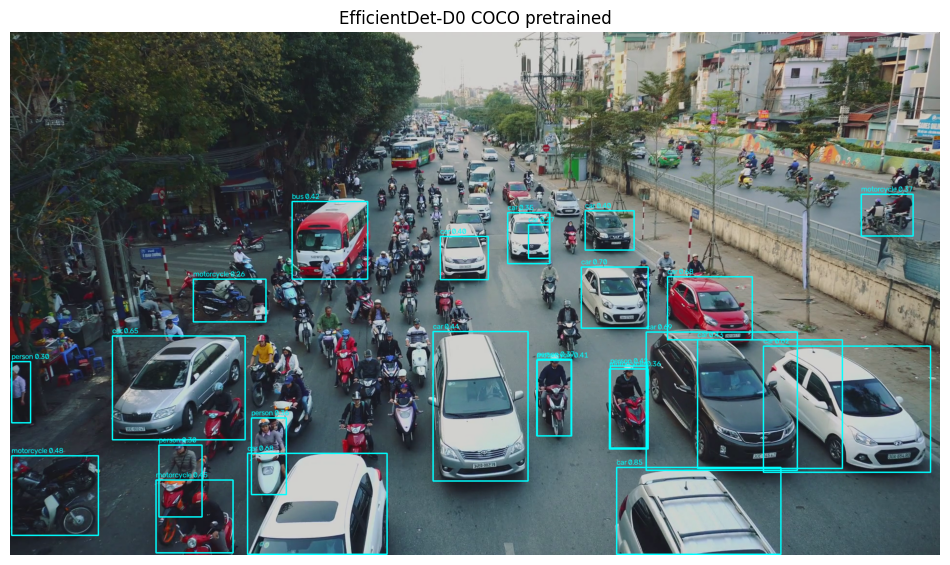

탐지 수: 25 저장: /content/effdet_runs/20260927_083522/pretrained_image_inference.png


In [11]:
# [필수 실행] 저장소 기본 이미지 추론. cv2.imshow 대신 matplotlib 사용
sample_image = REPO_DIR / 'test' / 'img.png'
assert sample_image.exists()
image_rgb, pred = infer_image(pretrained_model, sample_image, threshold=0.25)
rendered = draw_prediction(image_rgb, pred, COCO_OBJECTS)
image_out = LOCAL_RUN_DIR / 'pretrained_image_inference.png'
cv2.imwrite(str(image_out), cv2.cvtColor(rendered, cv2.COLOR_RGB2BGR))
plt.figure(figsize=(12,8)); plt.imshow(rendered); plt.axis('off'); plt.title('EfficientDet-D0 COCO pretrained'); plt.show()
print('탐지 수:', len(pred['scores']), '저장:', image_out)

## 4. 영상에서 객체 탐지

교안의 축구 영상 대신 데이터셋에 포함된 `SampleVideo_LowQuality.mp4`를 사용했습니다. COCO 사전학습 모델로 앞 300프레임을 처리하고 MP4로 저장했습니다. 처리한 영상의 첫·중간·마지막 프레임은 마지막 결과 정리 셀에서 확인할 수 있습니다. 미세조정 모델의 영상 비교와 처리 속도 측정은 이번 범위에서 수행하지 않았습니다.

In [12]:
VIDEO_PATH = str(DATA_SOURCE / 'SampleVideo_LowQuality.mp4')  # 이 셀에서만 수정: 예 '/content/drive/MyDrive/.../soccer.gif'
VIDEO_SOURCE = resolve_optional_path(VIDEO_PATH, '영상')

def run_video_inference(video_path, out_path, max_frames=300, threshold=0.25):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'영상을 열 수 없습니다: {video_path}')
    fps = cap.get(cv2.CAP_PROP_FPS)
    if not np.isfinite(fps) or fps <= 0: fps = 20.0
    writer = None
    count = 0
    try:
        while count < max_frames:
            ok, bgr = cap.read()
            if not ok: break
            tmp_frame = LOCAL_RUN_DIR / '_video_frame.jpg'
            cv2.imwrite(str(tmp_frame), bgr)
            rgb, one_pred = infer_image(pretrained_model, tmp_frame, threshold=threshold)
            drawn = draw_prediction(rgb, one_pred, COCO_OBJECTS)
            out_bgr = cv2.cvtColor(drawn, cv2.COLOR_RGB2BGR)
            if writer is None:
                h,w = out_bgr.shape[:2]
                writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*'mp4v'), fps, (w,h))
                assert writer.isOpened(), 'MP4 writer를 열 수 없습니다.'
            writer.write(out_bgr)
            count += 1
    finally:
        cap.release()
        if writer is not None: writer.release()
        (LOCAL_RUN_DIR/'_video_frame.jpg').unlink(missing_ok=True)
    if count == 0: raise RuntimeError('읽은 프레임이 0개입니다.')
    return {'frames': count, 'fps': fps, 'output': str(out_path)}

if VIDEO_SOURCE is None:
    video_status = {'status': 'SKIP_INCOMPLETE', 'reason': 'VIDEO_PATH 미지정'}
else:
    video_status = {'status': 'DONE', **run_video_inference(
        VIDEO_SOURCE, LOCAL_RUN_DIR/'pretrained_video_inference.mp4', MAX_VIDEO_FRAMES)}
(LOCAL_RUN_DIR/'video_status.json').write_text(json.dumps(video_status, indent=2, ensure_ascii=False), encoding='utf-8')
print(video_status)

{'status': 'DONE', 'frames': 300, 'fps': 24.0, 'output': '/content/effdet_runs/20260927_083522/pretrained_video_inference.mp4'}


## 5. 데이터셋 구조와 검증

원본 데이터는 수정하지 않습니다. ZIP은 /content에 해제합니다. `train/valid/test`별 COCO JSON이 있는 root를 찾습니다. Apply/No Apply 등 후보가 여러 개면 `DATASET_HINT`를 더 구체적으로 둡니다.

In [13]:
EXTRACT_DIR = CONTENT / 'effdet_source_extract' / RUN_ID
EXTRACT_MARKER = EXTRACT_DIR / '_EXTRACT_COMPLETE.json'

def find_coco_roots(base, max_depth=7):
    roots = []
    for cur, dirs, files in limited_walk(base, max_depth):
        names = {norm_text(x): x for x in dirs}
        if all(s in names for s in ('train','valid','test')):
            ok = True
            for split in ('train','valid','test'):
                split_dir = cur / names[split]
                if len(list(split_dir.glob('*.json'))) != 1:
                    ok = False
            if ok: roots.append(cur)
    return sorted(set(roots))

def safe_extract_zip(zip_path, destination):
    destination = Path(destination).resolve()
    with zipfile.ZipFile(zip_path) as zf:
        for member in zf.infolist():
            target = (destination / member.filename).resolve()
            assert destination == target or destination in target.parents, f'위험한 ZIP 경로: {member.filename}'
        zf.extractall(destination)

if DATA_SOURCE.is_file() and DATA_SOURCE.suffix.lower() == '.zip':
    zst = DATA_SOURCE.stat()
    zip_sig = {'zip': str(DATA_SOURCE), 'bytes': zst.st_size, 'mtime_ns': zst.st_mtime_ns}
    if EXTRACT_MARKER.exists():
        # 재실행: 완료 marker가 같은 ZIP을 가리키면 다시 풀지 않습니다.
        assert json.loads(EXTRACT_MARKER.read_text(encoding='utf-8')).get('zip') == zip_sig, \
            f'같은 RUN_ID에 다른 ZIP 해제본이 있습니다: {EXTRACT_DIR}'
        print('완료된 압축 해제본 재사용:', EXTRACT_DIR)
    else:
        assert not EXTRACT_DIR.exists(), f'완료 marker 없는 해제 폴더입니다. 확인 후 삭제하세요: {EXTRACT_DIR}'
        partial = EXTRACT_DIR.with_name(EXTRACT_DIR.name + '.partial')
        if partial.exists():
            shutil.rmtree(partial)  # 이전에 중단된 /content 로컬 해제 잔여물만 삭제
        partial.mkdir(parents=True)
        safe_extract_zip(DATA_SOURCE, partial)
        write_json_atomic(partial / EXTRACT_MARKER.name,
                          {'zip': zip_sig, 'completed_at': datetime.now(timezone.utc).isoformat()})
        os.replace(partial, EXTRACT_DIR)
    search_base = EXTRACT_DIR
else:
    search_base = DATA_SOURCE
    # 교안의 학습 부분과 동일한 증강 COCO 버전으로 통일합니다.
    preferred_root = DATA_SOURCE / 'Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco'
    if preferred_root.is_dir():
        search_base = preferred_root

SOURCE_ROOT = unique_or_stop(find_coco_roots(search_base), 'COCO train/valid/test root')
SOURCE_JSON = {s: next((SOURCE_ROOT/s).glob('*.json')) for s in ('train','valid','test')}
print('선택된 원본 root:', SOURCE_ROOT)
print({k: str(v) for k,v in SOURCE_JSON.items()})

선택된 원본 root: /root/.cache/kagglehub/datasets/pkdarabi/vehicle-detection-image-dataset/versions/7/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco
{'train': '/root/.cache/kagglehub/datasets/pkdarabi/vehicle-detection-image-dataset/versions/7/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco/train/_annotations.coco.json', 'valid': '/root/.cache/kagglehub/datasets/pkdarabi/vehicle-detection-image-dataset/versions/7/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco/valid/_annotations.coco.json', 'test': '/root/.cache/kagglehub/datasets/pkdarabi/vehicle-detection-image-dataset/versions/7/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco/test/_annotations.coco.json'}


In [14]:
from PIL import Image

IMAGE_EXTS = {'.jpg','.jpeg','.png','.bmp','.webp'}
SPLITS = ('train','valid','test')
def load_coco(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def category_signature(coco):
    return [(int(c['id']), str(c['name'])) for c in sorted(coco['categories'], key=lambda x:int(x['id']))]

def bbox_problem(box, meta):
    try:
        vals = [float(v) for v in box]
    except (TypeError, ValueError):
        return f'non-numeric bbox {box}'
    if len(vals) != 4 or not all(math.isfinite(v) for v in vals):
        return f'invalid bbox {box}'
    x, y, w, h = vals
    if w <= 0 or h <= 0:
        return f'non-positive bbox size {box}'
    if meta is not None and (x < -1 or y < -1 or x+w > float(meta['width'])+1 or y+h > float(meta['height'])+1):
        return f'bbox outside image {box} (image {meta["width"]}x{meta["height"]})'
    return None

def validate_coco_split(split_dir, json_path, verify_pixels=True):
    """검증만 하고 수정하지 않는다. 중단 여부는 호출부가 error_count로 결정한다."""
    coco = load_coco(json_path)
    assert all(k in coco for k in ('images','annotations','categories'))
    image_by_id = {int(x['id']): x for x in coco['images']}
    assert len(image_by_id) == len(coco['images']), '중복 image id'
    category_ids = {int(x['id']) for x in coco['categories']}
    errors, seen_ann, per_cat, notes = [], Counter(), Counter(), Counter()
    for ann in coco['annotations']:
        aid, iid, cid = ann.get('id'), int(ann['image_id']), int(ann['category_id'])
        seen_ann[aid] += 1
        if not isinstance(aid, int) or aid <= 0: notes['annotation_id_not_positive_int'] += 1
        if 'iscrowd' not in ann: notes['iscrowd_missing'] += 1
        elif int(ann['iscrowd']) != 0: notes['iscrowd_nonzero'] += 1
        if 'area' not in ann: notes['area_missing'] += 1
        if iid not in image_by_id: errors.append(f'ann {aid}: missing image_id {iid}')
        if cid not in category_ids: errors.append(f'ann {aid}: missing category_id {cid}')
        per_cat[cid] += 1
        problem = bbox_problem(ann.get('bbox', []), image_by_id.get(iid))
        if problem: errors.append(f'ann {aid} (image {iid}): {problem}')
    notes['annotation_id_duplicates'] = sum(v-1 for v in seen_ann.values() if v > 1)
    for meta in coco['images']:
        p = Path(split_dir) / meta['file_name']
        if not p.exists():
            errors.append(f'missing image file {meta["file_name"]}'); continue
        if verify_pixels:
            try:
                with Image.open(p) as im:
                    im.verify()
                with Image.open(p) as im:
                    if im.size != (int(meta['width']), int(meta['height'])):
                        errors.append(f'{meta["file_name"]}: size {im.size} != json {(meta["width"], meta["height"])}')
            except Exception as e:
                errors.append(f'{meta["file_name"]}: image decode {e}')
    return {'images':len(coco['images']), 'annotations':len(coco['annotations']),
            'categories':len(coco['categories']), 'category_signature':category_signature(coco),
            'annotations_per_category': {str(c): per_cat.get(c, 0) for c in sorted(category_ids)},
            'id_notes': dict(notes), 'error_count': len(errors), 'errors': errors[:1000]}

def compact(report):
    return {k: v for k, v in report.items() if k != 'errors'}

# 박스·파일 오류는 자동 정리하지 않고 보고서를 남긴 뒤 중단합니다.
source_reports = {s: validate_coco_split(SOURCE_ROOT/s, SOURCE_JSON[s]) for s in SPLITS}
write_json_atomic(LOCAL_RUN_DIR/'source_validation_report.json', source_reports)
failed = {s: r['error_count'] for s, r in source_reports.items() if r['error_count']}
if failed:
    for s in failed:
        print(f'[{s}] 오류 예시:', *source_reports[s]['errors'][:10], sep='\n  ')
    raise RuntimeError(f'원본 COCO 검증 실패 {failed}. 자동 정리 없이 중단합니다. '
                       f'보고서: {LOCAL_RUN_DIR/"source_validation_report.json"}')
assert source_reports['train']['category_signature'] == source_reports['valid']['category_signature'] == source_reports['test']['category_signature'], \
       'split 사이 category_id/name 구성이 다릅니다.'
print(json.dumps({s: compact(r) for s, r in source_reports.items()}, indent=2, ensure_ascii=False))
print('id_notes는 로컬 작업본에서 annotation id 1..N 재번호, iscrowd/area 기본값으로 처리합니다.')

{
  "train": {
    "images": 136,
    "annotations": 2724,
    "categories": 6,
    "category_signature": [
      [
        0,
        "cars"
      ],
      [
        1,
        "Bus"
      ],
      [
        2,
        "Car"
      ],
      [
        3,
        "Motorcycle"
      ],
      [
        4,
        "Pickup"
      ],
      [
        5,
        "Truck"
      ]
    ],
    "annotations_per_category": {
      "0": 0,
      "1": 31,
      "2": 2023,
      "3": 355,
      "4": 251,
      "5": 64
    },
    "id_notes": {
      "annotation_id_not_positive_int": 1,
      "annotation_id_duplicates": 0
    },
    "error_count": 0
  },
  "valid": {
    "images": 28,
    "annotations": 563,
    "categories": 6,
    "category_signature": [
      [
        0,
        "cars"
      ],
      [
        1,
        "Bus"
      ],
      [
        2,
        "Car"
      ],
      [
        3,
        "Motorcycle"
      ],
      [
        4,
        "Pickup"
      ],
      [
        5,
        "Truck

## 6. 로컬 작업본과 category_id 재매핑

저장소 loader는 내부에서 `category_id - 1`을 사용합니다. 원본 ID의 1..N 연속성은 보장되지 않으므로, 세 split의 category 구성을 확인한 뒤 로컬 복사본에서만 1..N으로 재매핑합니다. 클래스명은 JSON의 실제 category에서 만듭니다.

- 작업본은 `datasets/vehicle_detection_<RUN_ID>`에 만듭니다. `.partial` 폴더에서 변환하고 완료 marker를 쓴 뒤 이름을 바꾸므로, 같은 RUN_ID로 다시 실행하면 재사용합니다.
- annotation id는 COCOeval을 위해 1..N으로 다시 매기고, 없는 `iscrowd`는 0, 없는 `area`는 w×h로 채웁니다.
- train annotation이 0개인 category는 경고만 하고 유지합니다. 삭제 여부는 실제 데이터를 본 뒤 따로 결정합니다.
- 잘못된 박스·누락 파일은 5절에서 보고서를 남기고 중단합니다. 자동 정리는 하지 않습니다.

In [15]:
# RUN_ID별 작업본: 다른 실행과 섞이지 않고, 같은 RUN_ID 재실행은 완료 marker로 재사용합니다.
PROJECT_NAME = f'vehicle_detection_{RUN_ID}'
WORK_DATASET = REPO_DIR / 'datasets' / PROJECT_NAME
CONVERSION_MARKER = WORK_DATASET / '_CONVERSION_COMPLETE.json'

source_categories = sorted(load_coco(SOURCE_JSON['train'])['categories'], key=lambda x:int(x['id']))
old_to_new = {int(cat['id']): i+1 for i,cat in enumerate(source_categories)}
OBJ_LIST = [str(cat['name']) for cat in source_categories]
assert len(OBJ_LIST) == len(set(OBJ_LIST)), '중복 클래스명이 있습니다.'

# train annotation이 0개인 category도 기본적으로 유지합니다. 제거 여부는 실제 데이터를 보고 따로 결정합니다.
ZERO_TRAIN_CATEGORIES = [
    {'source_id': int(cat['id']), 'new_id': old_to_new[int(cat['id'])], 'name': str(cat['name']),
     **{s: source_reports[s]['annotations_per_category'][str(cat['id'])] for s in SPLITS}}
    for cat in source_categories
    if source_reports['train']['annotations_per_category'][str(cat['id'])] == 0]
if ZERO_TRAIN_CATEGORIES:
    print('경고: train annotation 0개 category (삭제하지 않고 유지):')
    for row in ZERO_TRAIN_CATEGORIES: print('  ', row)

def convert_split_coco(coco):
    stats = Counter()
    for cat in coco['categories']:
        cat['id'] = old_to_new[int(cat['id'])]
    for new_id, ann in enumerate(coco['annotations'], start=1):
        if ann.get('id') != new_id: stats['annotation_id_renumbered'] += 1
        ann['id'] = new_id                                   # COCOeval용 1..N 고유 id
        ann['category_id'] = old_to_new[int(ann['category_id'])]
        if 'iscrowd' not in ann:
            ann['iscrowd'] = 0; stats['iscrowd_default_0'] += 1
        if 'area' not in ann:
            ann['area'] = float(ann['bbox'][2]) * float(ann['bbox'][3]); stats['area_default_wh'] += 1
    return coco, dict(stats)

expected_marker = {
    'source_fingerprint': {s: {'json': str(SOURCE_JSON[s]), 'sha256': sha256_file(SOURCE_JSON[s])} for s in SPLITS},
    'old_to_new_category_id': {str(k): v for k, v in old_to_new.items()},
    'obj_list': OBJ_LIST,
}
if CONVERSION_MARKER.exists():
    marker = json.loads(CONVERSION_MARKER.read_text(encoding='utf-8'))
    if any(marker.get(k) != v for k, v in expected_marker.items()):
        raise RuntimeError(f'같은 RUN_ID 작업본이 다른 원본/매핑으로 만들어졌습니다: {WORK_DATASET}')
    conversion_stats = marker['conversion_stats']
    print('완료된 작업본 재사용:', WORK_DATASET)
else:
    if WORK_DATASET.exists():
        raise FileExistsError(f'완료 marker 없는 작업본입니다. 확인 후 직접 삭제하세요: {WORK_DATASET}')
    partial = WORK_DATASET.with_name(PROJECT_NAME + '.partial')
    assert partial.parent == REPO_DIR / 'datasets'
    if partial.exists():
        shutil.rmtree(partial)  # 이전에 중단된 /content 로컬 변환 잔여물만 삭제
    (partial/'annotations').mkdir(parents=True)
    conversion_stats = {}
    for split in SPLITS:
        (partial/split).mkdir()
        coco = load_coco(SOURCE_JSON[split])
        for meta in coco['images']:
            dst = partial/split/meta['file_name']
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(SOURCE_ROOT/split/meta['file_name'], dst)
        coco, conversion_stats[split] = convert_split_coco(coco)
        (partial/'annotations'/f'instances_{split}.json').write_text(json.dumps(coco, ensure_ascii=False), encoding='utf-8')
    write_json_atomic(partial/CONVERSION_MARKER.name,
                      {**expected_marker, 'conversion_stats': conversion_stats,
                       'zero_train_categories': ZERO_TRAIN_CATEGORIES,
                       'completed_at': datetime.now(timezone.utc).isoformat()})
    os.replace(partial, WORK_DATASET)

mapping = {'source_root':str(SOURCE_ROOT), 'working_root':str(WORK_DATASET),
           'old_to_new_category_id':old_to_new, 'obj_list':OBJ_LIST,
           'zero_train_categories_kept': ZERO_TRAIN_CATEGORIES, 'conversion_stats': conversion_stats}
write_json_atomic(LOCAL_RUN_DIR/'category_mapping.json', mapping)
print('동적 클래스:', OBJ_LIST)
print('ID 매핑:', old_to_new)
print('변환 통계:', conversion_stats)

경고: train annotation 0개 category (삭제하지 않고 유지):
   {'source_id': 0, 'new_id': 1, 'name': 'cars', 'train': 0, 'valid': 0, 'test': 0}
동적 클래스: ['cars', 'Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']
ID 매핑: {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6}
변환 통계: {'train': {'annotation_id_renumbered': 2724}, 'valid': {'annotation_id_renumbered': 563}, 'test': {'annotation_id_renumbered': 254}}


In [16]:
# [필수 실행] 변환본을 다시 독립 검증
converted_reports = {}
for split in SPLITS:
    json_path = WORK_DATASET/'annotations'/f'instances_{split}.json'
    rep = validate_coco_split(WORK_DATASET/split, json_path)
    assert rep['error_count'] == 0, f'{split}: 변환본 검증 실패 {rep["errors"][:10]}'
    ids = [x[0] for x in rep['category_signature']]
    assert ids == list(range(1, len(OBJ_LIST)+1)), f'{split}: category_id가 1..N이 아닙니다.'
    assert [x[1] for x in rep['category_signature']] == OBJ_LIST
    anns = load_coco(json_path)['annotations']
    assert [a['id'] for a in anns] == list(range(1, len(anns)+1)), f'{split}: annotation id가 1..N이 아닙니다.'
    assert all('iscrowd' in a and 'area' in a for a in anns), f'{split}: iscrowd/area 누락'
    converted_reports[split] = compact(rep)
print(json.dumps(converted_reports, indent=2, ensure_ascii=False))

{
  "train": {
    "images": 136,
    "annotations": 2724,
    "categories": 6,
    "category_signature": [
      [
        1,
        "cars"
      ],
      [
        2,
        "Bus"
      ],
      [
        3,
        "Car"
      ],
      [
        4,
        "Motorcycle"
      ],
      [
        5,
        "Pickup"
      ],
      [
        6,
        "Truck"
      ]
    ],
    "annotations_per_category": {
      "1": 0,
      "2": 31,
      "3": 2023,
      "4": 355,
      "5": 251,
      "6": 64
    },
    "id_notes": {
      "annotation_id_duplicates": 0
    },
    "error_count": 0
  },
  "valid": {
    "images": 28,
    "annotations": 563,
    "categories": 6,
    "category_signature": [
      [
        1,
        "cars"
      ],
      [
        2,
        "Bus"
      ],
      [
        3,
        "Car"
      ],
      [
        4,
        "Motorcycle"
      ],
      [
        5,
        "Pickup"
      ],
      [
        6,
        "Truck"
      ]
    ],
    "annotations_per_categ

In [17]:
# [필수 실행] split 누수 점검: 파일명과 파일 내용 SHA-256 교집합
from collections import defaultdict

def image_paths(split):
    return sorted(p for p in (WORK_DATASET/split).rglob('*') if p.suffix.lower() in IMAGE_EXTS)

def leakage_report():
    by_split = {s:image_paths(s) for s in ('train','valid','test')}
    names = {s:{p.name for p in ps} for s,ps in by_split.items()}
    hashes = {s:{sha256_file(p):p.name for p in ps} for s,ps in by_split.items()}
    report = {}
    for a,b in (('train','valid'),('train','test'),('valid','test')):
        report[f'{a}-{b}'] = {
            'same_names': sorted(names[a] & names[b])[:30],
            'same_content_hashes': sorted(set(hashes[a]) & set(hashes[b]))[:30]
        }
    return report

leaks = leakage_report()
(LOCAL_RUN_DIR/'split_leakage.json').write_text(json.dumps(leaks, indent=2), encoding='utf-8')
print(json.dumps(leaks, indent=2))
if any(v['same_names'] or v['same_content_hashes'] for v in leaks.values()):
    print('경고: split 누수 후보가 있습니다. 학습 전에 직접 확인하세요.')

{
  "train-valid": {
    "same_names": [],
    "same_content_hashes": []
  },
  "train-test": {
    "same_names": [],
    "same_content_hashes": []
  },
  "valid-test": {
    "same_names": [],
    "same_content_hashes": []
  }
}


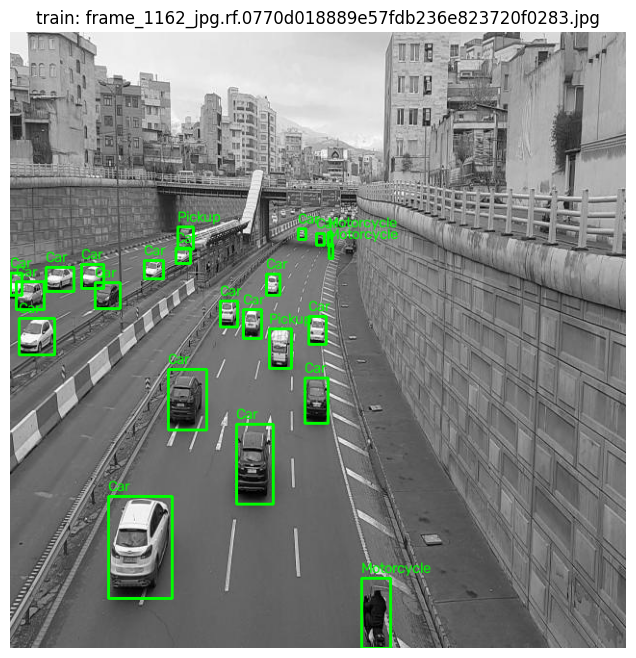

PosixPath('/content/effdet_runs/20260927_083522/gt_train_0.png')

In [18]:
# [필수 실행] GT annotation 한 장 시각화

def show_ground_truth(split='train', index=0):
    coco = load_coco(WORK_DATASET/'annotations'/f'instances_{split}.json')
    meta = coco['images'][index % len(coco['images'])]
    rgb = np.array(Image.open(WORK_DATASET/split/meta['file_name']).convert('RGB'))
    cat = {int(x['id']):x['name'] for x in coco['categories']}
    for ann in coco['annotations']:
        if int(ann['image_id']) != int(meta['id']): continue
        x,y,w,h = map(int,ann['bbox'])
        cv2.rectangle(rgb,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(rgb,cat[int(ann['category_id'])],(x,max(15,y-5)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),1)
    out = LOCAL_RUN_DIR/f'gt_{split}_{index}.png'
    Image.fromarray(rgb).save(out)
    plt.figure(figsize=(12,8)); plt.imshow(rgb); plt.axis('off'); plt.title(f'{split}: {meta["file_name"]}'); plt.show()
    return out

show_ground_truth('train', 0)

## 7. Mean/std와 anchor 확인

평가 데이터가 학습 설정에 섞이지 않도록 train만 사용합니다. mean/std는 이미지별 평균을 다시 평균내는 대신 전체 픽셀 기준으로 계산합니다.

Anchor 추천값은 train의 박스 크기에서 구한 휴리스틱입니다. 8절 `ANCHOR_MODE`로 추천값(`recommended`, 기본)과 저장소 COCO 기본값(`coco_default`)을 고를 수 있습니다. 두 설정의 validation 비교(ablation)는 이 노트북에서 수행하지 않았으므로, 추천값이 더 좋다고 판단하지 않습니다.

In [19]:
def compute_train_mean_std(max_images=None):
    paths = image_paths('train')
    if max_images is not None: paths = paths[:max_images]
    total = np.zeros(3, dtype=np.float64)
    total_sq = np.zeros(3, dtype=np.float64)
    pixels = 0
    for p in paths:
        arr = np.asarray(Image.open(p).convert('RGB'), dtype=np.float64) / 255.0
        flat = arr.reshape(-1,3)
        total += flat.sum(axis=0)
        total_sq += np.square(flat).sum(axis=0)
        pixels += len(flat)
    assert pixels > 0
    mean = total / pixels
    std = np.sqrt(np.maximum(total_sq / pixels - mean**2, 0))
    return mean, std, len(paths), pixels

TRAIN_MEAN, TRAIN_STD, stat_images, stat_pixels = compute_train_mean_std()
assert np.all(TRAIN_STD > 0)
print('RGB mean:', TRAIN_MEAN.tolist())
print('RGB std :', TRAIN_STD.tolist())
print('images/pixels:', stat_images, stat_pixels)

RGB mean: [0.4646008676002728, 0.47094062285982613, 0.4691757590745799]
RGB std : [0.1672425214913095, 0.16622922338465185, 0.1667466435685184]
images/pixels: 136 55705600


In [20]:
def analyze_train_anchors(input_size=512):
    coco = load_coco(WORK_DATASET/'annotations'/'instances_train.json')
    images = {int(x['id']):x for x in coco['images']}
    ratios, resized_sizes = [], []
    per_class = defaultdict(int)
    for ann in coco['annotations']:
        x,y,w,h = map(float,ann['bbox'])
        if w <= 0 or h <= 0: continue
        meta = images[int(ann['image_id'])]
        resize = input_size / max(float(meta['width']), float(meta['height']))
        ratios.append(w/h)
        resized_sizes.append(math.sqrt(w*h) * resize)
        per_class[int(ann['category_id'])] += 1
    ratios = np.asarray(ratios)
    sizes = np.asarray(resized_sizes)
    assert len(ratios) > 0 and np.all(ratios > 0)

    ratio_q = np.exp(np.quantile(np.log(ratios), [0.2,0.5,0.8]))
    anchor_ratios = [(round(math.sqrt(r),3), round(1/math.sqrt(r),3)) for r in ratio_q]
    bases = np.array([32,64,128,256,512], dtype=float)  # D0, anchor_scale=4, P3..P7
    nearest = bases[np.argmin(abs(np.log2(sizes[:,None]/bases[None,:])), axis=1)]
    residual = sizes / nearest
    anchor_scales = np.round(np.quantile(residual, [0.2,0.5,0.8]),3).tolist()
    assert len(anchor_ratios) == 3 and len(anchor_scales) == 3
    return {'anchor_ratios':anchor_ratios, 'anchor_scales':anchor_scales,
            'ratio_quantiles':ratio_q.tolist(), 'resized_size_quantiles':np.quantile(sizes,[.1,.5,.9]).tolist(),
            'per_class_annotations':{OBJ_LIST[k-1]:v for k,v in sorted(per_class.items())},
            'ratios':ratios, 'sizes':sizes}

ANCHOR_STATS = analyze_train_anchors()
print({k:v for k,v in ANCHOR_STATS.items() if k not in ('ratios','sizes')})

{'anchor_ratios': [(0.724, 1.382), (0.816, 1.225), (0.91, 1.099)], 'anchor_scales': [0.24, 0.437, 0.813], 'ratio_quantiles': [0.5238095238095238, 0.6666666666666666, 0.8275862068965517], 'resized_size_quantiles': [6.118823416311343, 13.994284547628721, 44.928387462716714], 'per_class_annotations': {'Bus': 31, 'Car': 2023, 'Motorcycle': 355, 'Pickup': 251, 'Truck': 64}}


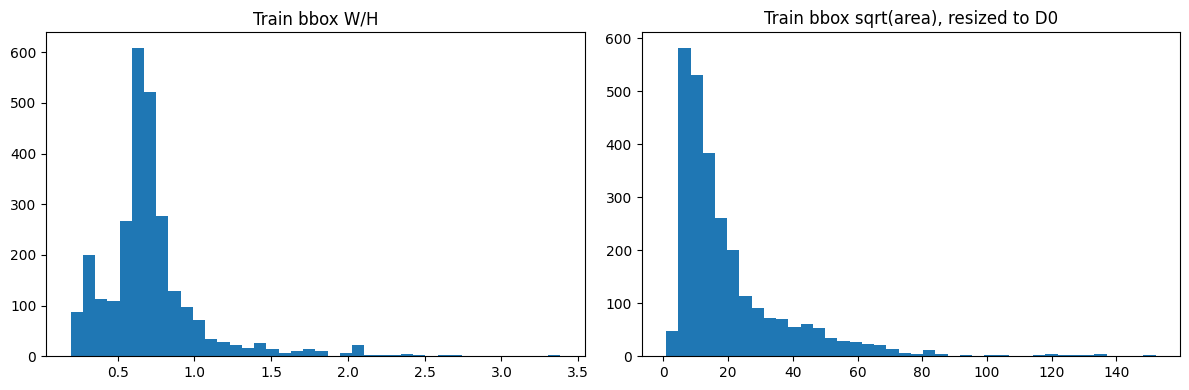

저장: /content/effdet_runs/20260927_083522/train_statistics.csv


In [21]:
# [필수 실행] 실측값 CSV와 이미지 저장
import csv

with (LOCAL_RUN_DIR/'train_statistics.csv').open('w', newline='', encoding='utf-8') as f:
    w = csv.writer(f)
    w.writerow(['metric','channel_or_quantile','value'])
    for c,v in zip(('R','G','B'), TRAIN_MEAN): w.writerow(['mean',c,float(v)])
    for c,v in zip(('R','G','B'), TRAIN_STD): w.writerow(['std',c,float(v)])
    for q,v in zip(('.2','.5','.8'), ANCHOR_STATS['ratio_quantiles']): w.writerow(['bbox_ratio',q,float(v)])
    for q,v in zip(('.1','.5','.9'), ANCHOR_STATS['resized_size_quantiles']): w.writerow(['bbox_size_512',q,float(v)])

fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].hist(ANCHOR_STATS['ratios'], bins=40); ax[0].set_title('Train bbox W/H')
ax[1].hist(ANCHOR_STATS['sizes'], bins=40); ax[1].set_title('Train bbox sqrt(area), resized to D0')
fig.tight_layout(); fig.savefig(LOCAL_RUN_DIR/'train_anchor_stats.png', dpi=150); plt.show()
print('저장:', LOCAL_RUN_DIR/'train_statistics.csv')

## 8. 학습 설정과 입력 확인

클래스 수는 임의로 고정하지 않고 JSON에서 읽은 `OBJ_LIST`를 사용합니다. YAML 설정은 로컬 작업본의 category_id와 맞춥니다. 학습 전에 loader가 반환하는 이미지 크기와 라벨 범위도 확인합니다.


In [22]:
import yaml

# 'recommended': 7절 train bbox 통계 휴리스틱(원래 설정) / 'coco_default': 저장소 COCO 기본 anchor
# 두 설정의 validation 비교(ablation)는 수행하지 않았습니다. 'recommended'가 더 낫다는 근거로 쓰지 마세요.
ANCHOR_MODE = 'recommended'
COCO_DEFAULT_ANCHORS = {'anchors_scales': '[2 ** 0, 2 ** (1.0 / 3.0), 2 ** (2.0 / 3.0)]',
                        'anchors_ratios': '[(1.0, 1.0), (1.4, 0.7), (0.7, 1.4)]'}
if ANCHOR_MODE == 'recommended':
    anchor_cfg = {'anchors_scales': repr(ANCHOR_STATS['anchor_scales']),
                  'anchors_ratios': repr(ANCHOR_STATS['anchor_ratios'])}
elif ANCHOR_MODE == 'coco_default':
    anchor_cfg = dict(COCO_DEFAULT_ANCHORS)
else:
    raise ValueError(f'ANCHOR_MODE는 recommended 또는 coco_default: {ANCHOR_MODE}')

PROJECT_YAML = REPO_DIR/'projects'/f'{PROJECT_NAME}.yml'
project_cfg = {
    'project_name': PROJECT_NAME,
    'train_set': 'train',
    'val_set': 'valid',
    'num_gpus': 1,
    'mean': [float(x) for x in TRAIN_MEAN],
    'std': [float(x) for x in TRAIN_STD],
    'anchors_scales': anchor_cfg['anchors_scales'],
    'anchors_ratios': anchor_cfg['anchors_ratios'],
    'obj_list': OBJ_LIST,
}
PROJECT_YAML.write_text(yaml.safe_dump(project_cfg, sort_keys=False, allow_unicode=True), encoding='utf-8')
shutil.copy2(PROJECT_YAML, LOCAL_RUN_DIR/PROJECT_YAML.name)
write_json_atomic(LOCAL_RUN_DIR/'anchor_config.json',
                  {'anchor_mode': ANCHOR_MODE, 'ablation_performed': False, **anchor_cfg})
loaded_cfg = yaml.safe_load(PROJECT_YAML.read_text(encoding='utf-8'))
assert loaded_cfg['obj_list'] == OBJ_LIST
assert len(eval(loaded_cfg['anchors_ratios'], {'__builtins__':{}}, {})) == 3
assert len(eval(loaded_cfg['anchors_scales'], {'__builtins__':{}}, {})) == 3
print('ANCHOR_MODE:', ANCHOR_MODE, '(anchor ablation 미수행)')
print(PROJECT_YAML.read_text(encoding='utf-8'))

ANCHOR_MODE: recommended (anchor ablation 미수행)
project_name: vehicle_detection_20260927_083522
train_set: train
val_set: valid
num_gpus: 1
mean:
- 0.4646008676002728
- 0.47094062285982613
- 0.4691757590745799
std:
- 0.1672425214913095
- 0.16622922338465185
- 0.1667466435685184
anchors_scales: '[0.24, 0.437, 0.813]'
anchors_ratios: '[(0.724, 1.382), (0.816, 1.225), (0.91, 1.099)]'
obj_list:
- cars
- Bus
- Car
- Motorcycle
- Pickup
- Truck



In [23]:
# [필수 실행] GPU 학습 없이 dataset loader 출력 shape와 label 범위 점검
from torchvision import transforms
from efficientdet.dataset import CocoDataset, Resizer, Normalizer, collater

smoke_ds = CocoDataset(
    root_dir=str(WORK_DATASET), set='train',
    transform=transforms.Compose([Normalizer(mean=project_cfg['mean'], std=project_cfg['std']), Resizer(512)]))
smoke = smoke_ds[0]
assert smoke['img'].shape == (512,512,3)
assert smoke['annot'].ndim == 2 and smoke['annot'].shape[1] == 5
if len(smoke['annot']):
    labels = smoke['annot'][:,4].numpy()
    assert labels.min() >= 0 and labels.max() < len(OBJ_LIST)
print('smoke image:', tuple(smoke['img'].shape), 'annotations:', tuple(smoke['annot'].shape))

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
smoke image: (512, 512, 3) annotations: (23, 5)


## 9. 2단계 학습: head-only 10 epoch → full 30 epoch

- head 셀: `RUN_HEAD_TRAIN`, `EXISTING_HEAD_CHECKPOINT`와 공통 파라미터(`HEAD_EPOCHS=10`, `LEARNING_RATE=1e-3`, `BATCH_SIZE=16`, `NUM_WORKERS`, `SAVE_INTERVAL`, `VAL_INTERVAL`)
- full 셀: `RUN_FULL_TRAIN`, `EXISTING_FULL_CHECKPOINT`, `FULL_EPOCHS=30`
- 각 단계 셀에서만 설정해 RUN_ID를 유지합니다. attempt 폴더가 이미 있으면 기록을 섞지 않고 중단합니다. 완료된 attempt는 summary로 재사용합니다.
- 학습 전 커널의 추론 모델을 CPU로 옮겨 GPU 메모리를 비웁니다.
- pinned train.py는 batch 예외를 `[Error]`로 출력하고 계속 진행합니다. 노트북이 이를 감지해 학습을 중단합니다. CUDA OOM이면 `OOM_FALLBACK_BATCH_SIZE=8`로 새 attempt를 한 번만 재시도하고(lr 유지) summary에 기록합니다.
- patched train.py는 validation마다 epoch/step/loss와 checkpoint 경로를 JSONL에 기록합니다. 이 기록으로 best checkpoint를 고릅니다.
- head checkpoint는 `head_init.pth`로 복사합니다. train.py가 파일명 끝 숫자를 resume step으로 읽으므로 full 단계의 추가 30 epoch를 분리합니다.
- Drive 보관: validation 기록이 바뀔 때와 stage 종료·중단 시 로그/JSONL/summary와 attempt별 best checkpoint 1개(`checkpoints/<attempt>_best.pth`)를 동기화합니다. 내용이 같으면 복사하지 않고, 바뀌면 임시 파일에 쓴 뒤 교체합니다.

In [25]:
# [필수 실행] 학습 공통 파라미터와 HEAD 단계 설정: 이 셀만 수정
RUN_HEAD_TRAIN = True
EXISTING_HEAD_CHECKPOINT = ''  # 이미 있는 head checkpoint를 쓸 때 지정
HEAD_ATTEMPT = 'head_01'       # 재시도 시 head_02처럼 새 이름 사용

HEAD_EPOCHS = 10
LEARNING_RATE = 1e-3
BATCH_SIZE = 16
OOM_FALLBACK_BATCH_SIZE = 8    # CUDA OOM일 때만 새 attempt로 1회 재시도(lr 유지, summary에 기록). None이면 중단
NUM_WORKERS = 2
SAVE_INTERVAL = 100            # step 단위 로컬 checkpoint. Drive에는 stage best만 보관
VAL_INTERVAL = 1               # epoch 단위 validation
DRIVE_SYNC_CHECK_SEC = 30      # validation 기록 변화 확인 주기. 변화가 있을 때만 Drive 동기화

# pinned train.py는 batch 예외를 '[Error]'로 출력하고 다음 batch로 넘어갑니다. 노트북에서 감지해 중단합니다.
BATCH_ERROR_MARKER = '[Error]'
OOM_PATTERNS = ('CUDA out of memory', 'OutOfMemoryError', 'CUBLAS_STATUS_ALLOC_FAILED')

class TrainingAbort(RuntimeError):
    def __init__(self, kind, message):
        super().__init__(message)
        self.kind = kind

def run_cmd_logged(args, log_path, on_tick=None, tick_sec=30, abort_on_batch_error=False):
    log_path = Path(log_path)
    log_path.parent.mkdir(parents=True, exist_ok=True)
    print('실행:', ' '.join(map(str,args)))
    env = dict(os.environ, PYTHONUNBUFFERED='1')
    error_seen, error_lines, timers = False, [], []
    with log_path.open('w', encoding='utf-8') as log_file:
        proc = subprocess.Popen(list(map(str,args)), cwd=REPO_DIR, env=env,
                                stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                                text=True, bufsize=1)
        last_tick = time.monotonic()
        try:
            for line in proc.stdout:
                print(line, end='')
                log_file.write(line)
                if error_seen and len(error_lines) < 400:
                    error_lines.append(line)
                if abort_on_batch_error and not error_seen and (
                        BATCH_ERROR_MARKER in line or any(p in line for p in OOM_PATTERNS)):
                    error_seen = True
                    error_lines.append(line)
                    log_file.flush()
                    # traceback 나머지가 로그에 남도록 5초 뒤 종료, 남아 있으면 60초 뒤 kill
                    timers = [threading.Timer(5, proc.terminate), threading.Timer(60, proc.kill)]
                    for t in timers:
                        t.daemon = True
                        t.start()
                if on_tick is not None and time.monotonic() - last_tick >= tick_sec:
                    log_file.flush()
                    try:
                        on_tick()
                    except Exception as e:  # 백업 실패는 경고만 남기고 stage 종료 시 다시 시도
                        print(f'[Drive sync 경고] {type(e).__name__}: {e}')
                    last_tick = time.monotonic()
        except BaseException:
            proc.kill()
            raise
        finally:
            return_code = proc.wait()
            for t in timers:
                t.cancel()
    if error_seen or (abort_on_batch_error and return_code):
        text = ''.join(error_lines) or log_path.read_text(encoding='utf-8', errors='replace')[-20000:]
        kind = 'oom' if any(p in text for p in OOM_PATTERNS) else 'error'
        raise TrainingAbort(kind, f'학습 중단(kind={kind}, returncode={return_code}). 로그: {log_path}')
    if return_code:
        raise subprocess.CalledProcessError(return_code, args)
    return log_path

def release_gpu_models():
    """커널이 잡고 있는 추론 모델을 CPU로 옮겨 학습 subprocess의 GPU 메모리를 확보."""
    import gc
    for name in ('pretrained_model', 'custom_model'):
        model = globals().get(name)
        if isinstance(model, torch.nn.Module):
            model.to('cpu')
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f'kernel CUDA allocated: {torch.cuda.memory_allocated()/2**20:.1f} MiB')

def read_validation_records(metrics_jsonl):
    path = Path(metrics_jsonl)
    assert path.exists(), f'validation 기록이 없습니다: {path}'
    records = [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]
    assert records, 'validation 기록이 비었습니다.'
    required = {'epoch','step','classification_loss','regression_loss','total_loss','is_best','checkpoint_path'}
    assert all(required <= set(r) for r in records), 'validation JSONL schema 불일치'
    assert all(np.isfinite(float(r['total_loss'])) for r in records), '비정상 validation loss'
    return records

def select_checkpoint_by_val(metrics_jsonl, ckpt_dir, csv_out):
    records = read_validation_records(metrics_jsonl)
    saved = [r for r in records if r['checkpoint_path']]
    assert saved, 'validation 개선 checkpoint 기록이 없습니다.'
    best = min(saved, key=lambda r: float(r['total_loss']))
    ckpt = Path(best['checkpoint_path']).resolve()
    assert ckpt.exists(), f'기록된 checkpoint가 없습니다: {ckpt}'
    assert ckpt.parent == Path(ckpt_dir).resolve(), 'checkpoint가 현재 attempt 폴더 밖을 가리킵니다.'
    import csv
    with Path(csv_out).open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(records[0].keys()))
        writer.writeheader(); writer.writerows(records)
    return ckpt, best

def latest_best_record(metrics_jsonl):
    """학습 중에도 읽을 수 있게 완성된 줄만 파싱. 마지막 is_best 기록이 현재 best."""
    path, best = Path(metrics_jsonl), None
    if not path.exists():
        return None
    for line in path.read_text(encoding='utf-8').splitlines():
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue
        if rec.get('is_best') and rec.get('checkpoint_path') and Path(rec['checkpoint_path']).exists():
            best = rec
    return best

SYNC_SUFFIXES = {'.jsonl', '.log', '.json', '.csv', '.txt', '.yml'}
def sync_stage_to_drive(stage_root, label, metrics_jsonl):
    """로그·validation 기록과 stage best checkpoint 1개를 Drive에 멱등 동기화."""
    if not SAVE_TO_DRIVE:
        return {}
    stage_root = Path(stage_root)
    best = latest_best_record(metrics_jsonl)
    if best:
        info_path = stage_root/'best_checkpoint.json'
        old = json.loads(info_path.read_text(encoding='utf-8')) if info_path.exists() else None
        if old != best:
            write_json_atomic(info_path, best)
    result = {}
    for p in sorted(stage_root.rglob('*')):
        if p.is_file() and p.suffix.lower() in SYNC_SUFFIXES and not p.name.startswith('.'):
            rel = p.relative_to(LOCAL_RUN_DIR)
            result[str(rel)] = sync_file(p, DRIVE_RESULT_DIR/rel)
    if best and SAVE_CHECKPOINT_TO_DRIVE:
        dst = DRIVE_RESULT_DIR/'checkpoints'/f'{label}_best.pth'  # attempt당 1개, 바뀔 때만 교체
        result[str(dst)] = sync_file(best['checkpoint_path'], dst)
    return result

def make_validation_sync(stage_root, label, metrics_jsonl):
    state = {'sig': None}
    def tick():
        p = Path(metrics_jsonl)
        if not p.exists():
            return
        st = p.stat()
        if (st.st_size, st.st_mtime_ns) != state['sig']:
            state['sig'] = (st.st_size, st.st_mtime_ns)
            res = sync_stage_to_drive(stage_root, label, metrics_jsonl)
            print(f'\n[Drive sync] {label}: validation 기록 변경, 갱신 {sum(v == "copied" for v in res.values())}개')
    return tick

def run_training_stage(attempt, head_only, epochs, init_weights, copy_init_as=None):
    summary_path = LOCAL_RUN_DIR/'training'/f'{attempt}_stage_summary.json'
    if summary_path.exists():
        done = json.loads(summary_path.read_text(encoding='utf-8'))
        if done.get('status') == 'complete' and Path(done['best_checkpoint']).exists():
            print('완료된 stage 재사용(재학습 안 함):', summary_path)
            return Path(done['best_checkpoint']), done
        raise RuntimeError(f'미완료/실패 stage 기록이 있습니다: {summary_path}. 새 attempt 이름을 쓰세요.')
    assert torch.cuda.is_available(), 'GPU 런타임에서만 학습하세요.'
    release_gpu_models()
    batch_plan = [BATCH_SIZE]
    if OOM_FALLBACK_BATCH_SIZE and OOM_FALLBACK_BATCH_SIZE < BATCH_SIZE:
        batch_plan.append(OOM_FALLBACK_BATCH_SIZE)
    summary = {'attempt': attempt, 'head_only': head_only, 'epochs': epochs, 'lr': LEARNING_RATE,
               'requested_batch_size': BATCH_SIZE, 'num_workers': NUM_WORKERS,
               'init_weights': str(init_weights), 'anchor_mode': ANCHOR_MODE,
               'status': 'running', 'tries': []}
    for i, bs in enumerate(batch_plan):
        label = attempt if i == 0 else f'{attempt}_bs{bs}'
        stage_root = LOCAL_RUN_DIR/'training'/label
        save_root, log_root = stage_root/'checkpoints', stage_root/'logs'
        assert not stage_root.exists(), f'기존 attempt와 섞지 않습니다: {stage_root}'
        stage_root.mkdir(parents=True)
        weights = Path(init_weights)
        if copy_init_as:
            # 'head_init.pth'처럼 끝이 숫자가 아닌 이름이면 train.py가 resume step을 0으로 해석
            weights = stage_root/copy_init_as
            shutil.copy2(init_weights, weights)
        metrics_jsonl = log_root/PROJECT_NAME/'tensorboard'/'validation_metrics.jsonl'
        try_rec = {'label': label, 'batch_size': bs, 'stage_root': str(stage_root), 'status': 'running'}
        summary['tries'].append(try_rec)
        write_json_atomic(summary_path, summary)
        try:
            run_cmd_logged([sys.executable,'train.py','-c','0','-p',PROJECT_NAME,'--head_only',str(head_only),
                            '--lr',str(LEARNING_RATE),'--batch_size',str(bs),'--num_workers',str(NUM_WORKERS),
                            '--num_epochs',str(epochs),'--val_interval',str(VAL_INTERVAL),
                            '--load_weights',weights,'--save_interval',str(SAVE_INTERVAL),
                            '--saved_path',save_root,'--log_path',log_root],
                           stage_root/'train_stdout.log',
                           on_tick=make_validation_sync(stage_root, label, metrics_jsonl),
                           tick_sec=DRIVE_SYNC_CHECK_SEC, abort_on_batch_error=True)
        except BaseException as e:
            kind = e.kind if isinstance(e, TrainingAbort) else type(e).__name__
            try_rec.update(status=f'aborted_{kind}', error=str(e))
            retry = isinstance(e, TrainingAbort) and e.kind == 'oom' and i + 1 < len(batch_plan)
            if not retry:
                summary['status'] = 'failed'
            write_json_atomic(summary_path, summary)
            try:
                sync_stage_to_drive(stage_root, label, metrics_jsonl)  # 실패 로그도 보관
                if SAVE_TO_DRIVE: sync_file(summary_path, DRIVE_RESULT_DIR/summary_path.relative_to(LOCAL_RUN_DIR))
            except Exception as sync_error:
                print('[Drive sync 경고]', sync_error)
            if retry:
                print(f'CUDA OOM: batch {bs} → {batch_plan[i+1]} 새 attempt로 재시도 (lr={LEARNING_RATE} 유지)')
                torch.cuda.empty_cache()
                continue
            raise
        best_ckpt, best = select_checkpoint_by_val(metrics_jsonl, save_root/PROJECT_NAME,
                                                   stage_root/'validation_metrics.csv')
        try_rec['status'] = 'complete'
        summary.update(status='complete', used_batch_size=bs, oom_fallback_used=(i > 0),
                       final_label=label, best_checkpoint=str(best_ckpt), best_record=best,
                       drive_checkpoint=str(DRIVE_RESULT_DIR/'checkpoints'/f'{label}_best.pth')
                       if SAVE_TO_DRIVE and SAVE_CHECKPOINT_TO_DRIVE else None,
                       completed_at=datetime.now(timezone.utc).isoformat())
        write_json_atomic(summary_path, summary)
        sync_stage_to_drive(stage_root, label, metrics_jsonl)   # stage 종료: 로그 + best checkpoint
        if SAVE_TO_DRIVE:
            sync_file(summary_path, DRIVE_RESULT_DIR/summary_path.relative_to(LOCAL_RUN_DIR))
        return best_ckpt, summary
    raise RuntimeError('batch plan을 모두 소진했습니다.')

if RUN_HEAD_TRAIN and EXISTING_HEAD_CHECKPOINT:
    raise ValueError('RUN_HEAD_TRAIN과 EXISTING_HEAD_CHECKPOINT 중 하나만 사용하세요.')
HEAD_BEST = Path(EXISTING_HEAD_CHECKPOINT).expanduser() if EXISTING_HEAD_CHECKPOINT else None
HEAD_SUMMARY = None
if RUN_HEAD_TRAIN:
    HEAD_BEST, HEAD_SUMMARY = run_training_stage(HEAD_ATTEMPT, True, HEAD_EPOCHS, WEIGHT_PATH)
    print('head best:', HEAD_BEST, HEAD_SUMMARY['best_record'])
    print('사용 batch:', HEAD_SUMMARY['used_batch_size'], 'OOM fallback:', HEAD_SUMMARY['oom_fallback_used'])
elif HEAD_BEST is not None:
    assert HEAD_BEST.exists(), f'기존 head checkpoint 없음: {HEAD_BEST}'
    print('기존 head checkpoint 사용:', HEAD_BEST)
else:
    print('SKIP: head 학습/기존 checkpoint 모두 미지정')

kernel CUDA allocated: 0.7 MiB
실행: /usr/bin/python3 train.py -c 0 -p vehicle_detection_20260927_083522 --head_only True --lr 0.001 --batch_size 16 --num_workers 2 --num_epochs 10 --val_interval 1 --load_weights /content/Yet-Another-EfficientDet-Pytorch/weights/efficientdet-d0.pth --save_interval 100 --saved_path /content/effdet_runs/20260927_083522/training/head_01/checkpoints --log_path /content/effdet_runs/20260927_083522/training/head_01/logs
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Warning] Ignoring Error(s) in loading state_dict for EfficientDetBackbone:
	size mismatch for classifier.header.pointwise_conv.conv.weight: copying a param with shape torch.Size([810, 64, 1, 1]) from checkpoint, the shape in current model is torch.Size([54, 64, 1, 1]).
	size mismatch for classifier.header.pointwise_conv.conv.bias: copying a param with shape torch.Size([810]) from 

In [26]:
# [필수 실행] FULL 단계 설정: 이 셀만 수정 (lr/batch/OOM fallback 등은 HEAD 셀의 공통 파라미터 사용)
RUN_FULL_TRAIN = True
EXISTING_FULL_CHECKPOINT = ''  # 이미 학습된 full checkpoint를 쓸 때 지정
FULL_ATTEMPT = 'full_01'       # 재시도 시 full_02처럼 새 이름 사용
FULL_EPOCHS = 30
HEAD_INIT_NAME = 'head_init.pth'  # 끝이 숫자가 아니어야 train.py가 resume step 0으로 해석

if RUN_FULL_TRAIN and EXISTING_FULL_CHECKPOINT:
    raise ValueError('RUN_FULL_TRAIN과 EXISTING_FULL_CHECKPOINT 중 하나만 사용하세요.')
FULL_BEST = Path(EXISTING_FULL_CHECKPOINT).expanduser() if EXISTING_FULL_CHECKPOINT else None
FULL_SUMMARY = None
if RUN_FULL_TRAIN:
    assert HEAD_BEST is not None and HEAD_BEST.exists(), '먼저 head checkpoint를 준비하세요.'
    FULL_BEST, FULL_SUMMARY = run_training_stage(FULL_ATTEMPT, False, FULL_EPOCHS, HEAD_BEST,
                                                 copy_init_as=HEAD_INIT_NAME)
    print('full best:', FULL_BEST, FULL_SUMMARY['best_record'])
    print('사용 batch:', FULL_SUMMARY['used_batch_size'], 'OOM fallback:', FULL_SUMMARY['oom_fallback_used'])
elif FULL_BEST is None:
    print('SKIP: full 학습/기존 checkpoint 모두 미지정. 이후 비교와 최종 평가는 미완료입니다.')

SELECTED_CKPT = FULL_BEST
checkpoint_backup = None
if SELECTED_CKPT is not None:
    SELECTED_CKPT = Path(SELECTED_CKPT)
    assert SELECTED_CKPT.exists(), f'checkpoint 없음: {SELECTED_CKPT}'
    size_mb = SELECTED_CKPT.stat().st_size / (1024**2)
    print(f'validation으로 선택된 checkpoint: {SELECTED_CKPT} ({size_mb:.1f} MB)')
    if SAVE_TO_DRIVE and SAVE_CHECKPOINT_TO_DRIVE:
        if FULL_SUMMARY and FULL_SUMMARY.get('drive_checkpoint'):
            checkpoint_backup = Path(FULL_SUMMARY['drive_checkpoint'])  # stage 종료 시 이미 동기화됨
            status = sync_file(SELECTED_CKPT, checkpoint_backup)
        else:
            checkpoint_backup = DRIVE_RESULT_DIR/'checkpoints'/f'selected_{SELECTED_CKPT.name}'
            status = sync_file(SELECTED_CKPT, checkpoint_backup)
        print('Drive checkpoint 보관:', checkpoint_backup, status)

kernel CUDA allocated: 0.7 MiB
실행: /usr/bin/python3 train.py -c 0 -p vehicle_detection_20260927_083522 --head_only False --lr 0.001 --batch_size 16 --num_workers 2 --num_epochs 30 --val_interval 1 --load_weights /content/effdet_runs/20260927_083522/training/full_01/head_init.pth --save_interval 100 --saved_path /content/effdet_runs/20260927_083522/training/full_01/checkpoints --log_path /content/effdet_runs/20260927_083522/training/full_01/logs
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Info] loaded weights: head_init.pth, resuming checkpoint from step: 0

  0%|          | 0/8 [00:00<?, ?it/s]/content/Yet-Another-EfficientDet-Pytorch/train.py:242: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_

## 10. Validation 평가와 confidence 비교

`RUN_VAL_COCO_EVAL=True`로 바꾸면 AP/AR 12개를 JSON과 CSV에 저장합니다. 실행 로그도 함께 남깁니다.

confidence는 0.25, 0.50, 0.75로 비교합니다. 같은 모델과 validation 표본에서 threshold 0.001로 얻은 예측을 공통으로 사용합니다. 클래스가 같고 IoU가 0.5 이상인 박스를 점수가 높은 순서대로 1:1 연결해 TP, FP, FN을 셉니다. 이 비교는 각 confidence에서의 값이며 AP/AR와는 구분합니다.

여기까지는 test 결과를 보지 않습니다.


In [27]:
def box_iou_xyxy(a, b):
    a, b = np.asarray(a,float), np.asarray(b,float)
    ix1, iy1 = max(a[0],b[0]), max(a[1],b[1])
    ix2, iy2 = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0,ix2-ix1) * max(0,iy2-iy1)
    area_a = max(0,a[2]-a[0]) * max(0,a[3]-a[1])
    area_b = max(0,b[2]-b[0]) * max(0,b[3]-b[1])
    return inter / (area_a+area_b-inter) if area_a+area_b-inter > 0 else 0.0

def greedy_counts(gt_boxes, gt_cls, pred_boxes, pred_cls, pred_scores, iou_thr=0.5):
    order = np.argsort(-np.asarray(pred_scores))
    used = set(); tp = fp = 0
    for pi in order:
        candidates = [(box_iou_xyxy(pred_boxes[pi], gt_boxes[gi]),gi)
                      for gi in range(len(gt_boxes)) if gi not in used and int(gt_cls[gi])==int(pred_cls[pi])]
        best_iou, best_gi = max(candidates, default=(0.0,None))
        if best_iou >= iou_thr:
            tp += 1; used.add(best_gi)
        else: fp += 1
    return tp, fp, len(gt_boxes)-len(used)

# synthetic helper tests
assert abs(box_iou_xyxy([0,0,10,10],[0,0,10,10])-1.0) < 1e-9
assert box_iou_xyxy([0,0,1,1],[2,2,3,3]) == 0
assert greedy_counts([[0,0,10,10]],[1],[[0,0,10,10]],[1],[.9]) == (1,0,0)
assert greedy_counts([[0,0,10,10]],[1],[[0,0,10,10]],[2],[.9]) == (0,1,1)
print('IoU/class-aware greedy synthetic tests: PASS')

IoU/class-aware greedy synthetic tests: PASS


In [28]:
# [비교 실험] 이 셀에서만 validation COCO 평가 여부를 선택
RUN_VAL_COCO_EVAL = True
VAL_EVAL_ATTEMPT = 'validation_coco_01'

def load_custom_model(checkpoint):
    model = EfficientDetBackbone(compound_coef=0, num_classes=len(OBJ_LIST),
             ratios=eval(project_cfg['anchors_ratios'], {'__builtins__':{}}, {}),
             scales=eval(project_cfg['anchors_scales'], {'__builtins__':{}}, {}))
    model.load_state_dict(safe_load_state(checkpoint), strict=True)
    return model.requires_grad_(False).eval().to(DEVICE)

def gt_for_image(coco, image_id):
    boxes, cls = [], []
    for ann in coco['annotations']:
        if int(ann['image_id']) != int(image_id): continue
        x,y,w,h = map(float,ann['bbox'])
        boxes.append([x,y,x+w,y+h]); cls.append(int(ann['category_id']))
    return np.asarray(boxes,float).reshape(-1,4), np.asarray(cls,int)

def cache_predictions(model, split='valid', limit=100):
    coco = load_coco(WORK_DATASET/'annotations'/f'instances_{split}.json')
    items = []
    for meta in coco['images'][:limit]:
        path = WORK_DATASET/split/meta['file_name']
        rgb, pred = infer_image(model, path, threshold=0.001, nms_iou=0.5,
                                mean=project_cfg['mean'], std=project_cfg['std'])
        gt_box, gt_cls = gt_for_image(coco, meta['id'])
        items.append({'meta':meta, 'rgb':rgb, 'gt_boxes':gt_box, 'gt_cls':gt_cls,
                      'pred_boxes':np.asarray(pred['rois'],float).reshape(-1,4),
                      'pred_cls':np.asarray(pred['class_ids'],int).reshape(-1)+1,
                      'scores':np.asarray(pred['scores'],float).reshape(-1)})
    return items

VAL_CACHE = None
if SELECTED_CKPT is not None:
    custom_model = load_custom_model(SELECTED_CKPT)
    if RUN_VAL_COCO_EVAL:
        val_eval_dir = LOCAL_RUN_DIR/'coco_eval'/VAL_EVAL_ATTEMPT
        assert not val_eval_dir.exists(), f'기존 평가 attempt와 섞지 않습니다: {val_eval_dir}'
        val_eval_dir.mkdir(parents=True)
        run_cmd_logged([sys.executable,'coco_eval.py','-c','0','-p',PROJECT_NAME,
                        '-w',SELECTED_CKPT,'--cuda',str(torch.cuda.is_available()),
                        '--override','True','--output_dir',val_eval_dir,
                        '--metrics_dir',val_eval_dir], val_eval_dir/'stdout.log')
    else:
        print('SKIP: RUN_VAL_COCO_EVAL=False. validation COCO AP/AR 파일은 아직 미생성입니다.')
    VAL_CACHE = cache_predictions(custom_model, 'valid', VAL_COMPARE_LIMIT)
    print('validation cache images:', len(VAL_CACHE))
else:
    print('SKIP_INCOMPLETE: 선택 checkpoint가 없어 validation 비교를 실행하지 않았습니다.')

실행: /usr/bin/python3 coco_eval.py -c 0 -p vehicle_detection_20260927_083522 -w /content/effdet_runs/20260927_083522/training/full_01/checkpoints/vehicle_detection_20260927_083522/efficientdet-d0_29_240.pth --cuda True --override True --output_dir /content/effdet_runs/20260927_083522/coco_eval/validation_coco_01 --metrics_dir /content/effdet_runs/20260927_083522/coco_eval/validation_coco_01
running coco-style evaluation on project vehicle_detection_20260927_083522, weights /content/effdet_runs/20260927_083522/training/full_01/checkpoints/vehicle_detection_20260927_083522/efficientdet-d0_29_240.pth...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

100%|██████████| 28/28 [00:09<00:00,  2.94it/s]
Loading and preparing results...
DONE (t=1.05s)
creating index...
index created!
BBox
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.33s).
Accumulating evaluation results...
DONE (t=0.10s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | 

{'threshold': 0.25, 'tp': 181, 'fp': 313, 'fn': 382, 'precision': 0.36639676113360325, 'recall': 0.32149200710479575, 'f1': 0.34247871333964053}
{'threshold': 0.5, 'tp': 45, 'fp': 3, 'fn': 518, 'precision': 0.9375, 'recall': 0.07992895204262877, 'f1': 0.14729950900163666}
{'threshold': 0.75, 'tp': 0, 'fp': 0, 'fn': 563, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


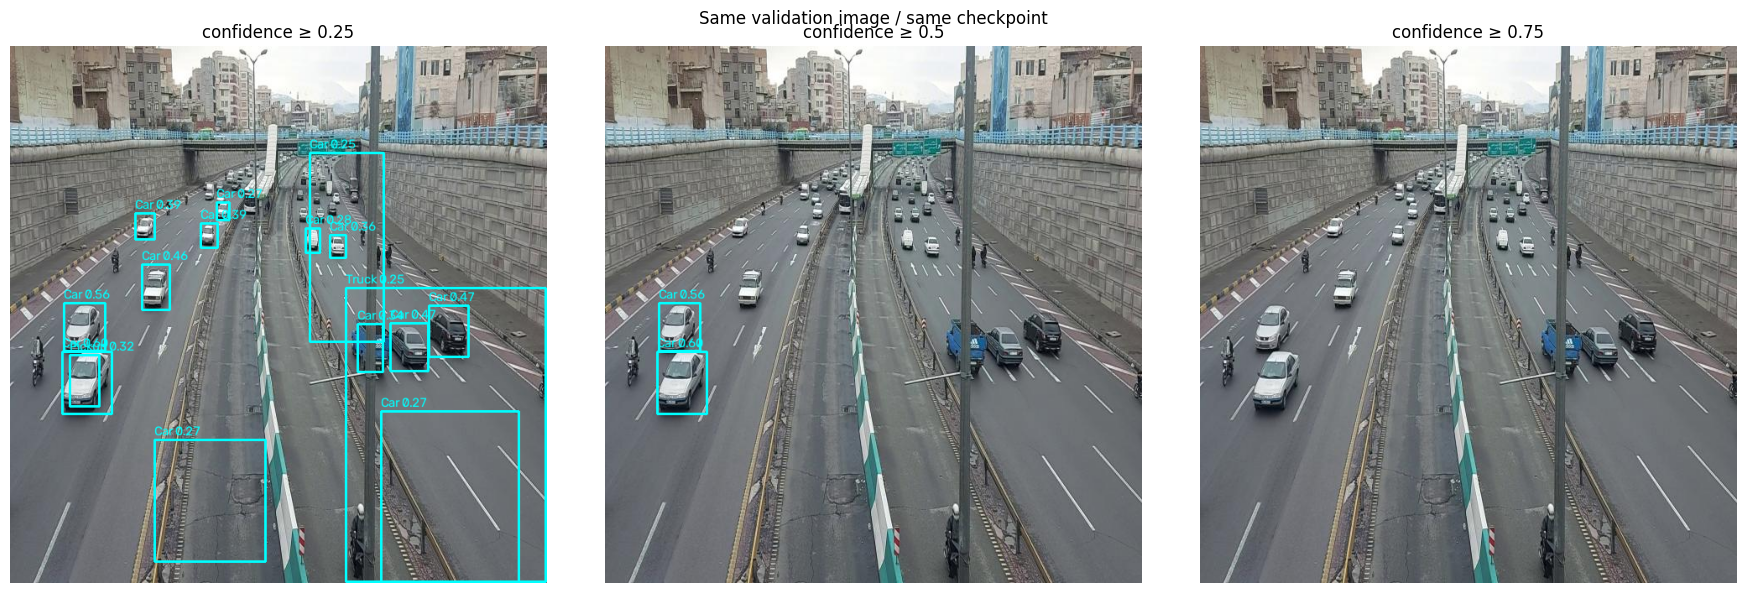

In [29]:
def evaluate_thresholds(cache, thresholds=THRESHOLDS):
    rows = []
    for thr in thresholds:
        tp=fp=fn=0
        for item in cache:
            keep = item['scores'] >= thr
            a,b,c = greedy_counts(item['gt_boxes'],item['gt_cls'],
                                  item['pred_boxes'][keep],item['pred_cls'][keep],item['scores'][keep],IOU_MATCH)
            tp+=a; fp+=b; fn+=c
        precision = tp/(tp+fp) if tp+fp else 0.0
        recall = tp/(tp+fn) if tp+fn else 0.0
        f1 = 2*precision*recall/(precision+recall) if precision+recall else 0.0
        rows.append({'threshold':thr,'tp':tp,'fp':fp,'fn':fn,
                     'precision':precision,'recall':recall,'f1':f1})
    return rows

if VAL_CACHE:
    threshold_rows = evaluate_thresholds(VAL_CACHE)
    with (LOCAL_RUN_DIR/'validation_threshold_comparison.csv').open('w',newline='',encoding='utf-8') as f:
        writer=csv.DictWriter(f,fieldnames=threshold_rows[0].keys()); writer.writeheader(); writer.writerows(threshold_rows)
    print(*threshold_rows, sep='\n')

    item = VAL_CACHE[0]
    fig, axes = plt.subplots(1,len(THRESHOLDS),figsize=(18,6))
    for ax,thr in zip(axes,THRESHOLDS):
        keep=item['scores']>=thr
        pred={'rois':item['pred_boxes'][keep], 'class_ids':item['pred_cls'][keep]-1, 'scores':item['scores'][keep]}
        ax.imshow(draw_prediction(item['rgb'],pred,OBJ_LIST)); ax.axis('off'); ax.set_title(f'confidence ≥ {thr}')
    fig.suptitle('Same validation image / same checkpoint'); fig.tight_layout()
    fig.savefig(LOCAL_RUN_DIR/'validation_threshold_qualitative.png',dpi=150); plt.show()
else:
    print('SKIP_INCOMPLETE: validation threshold CSV/이미지 미생성')

## 11. Test 결과 확인

validation에서 checkpoint와 confidence를 정한 뒤 `RUN_FINAL_TEST=True`로 바꿉니다. 선택한 조건을 그대로 쓰고, test 결과를 보고 다시 조정하지 않습니다.

같은 RUN_ID에서 test가 끝났으면 완료 기록을 남겨 재실행을 막습니다. 오류 확인 등으로 반복이 꼭 필요하면 `ALLOW_REPEAT_FINAL_TEST=True`로 바꾸고 `TEST_ATTEMPT`도 새 이름으로 지정합니다. 이 제한은 같은 RUN_ID 안에서만 적용됩니다.


실행: /usr/bin/python3 coco_eval.py -c 0 -p vehicle_detection_20260927_083522_test -w /content/effdet_runs/20260927_083522/training/full_01/checkpoints/vehicle_detection_20260927_083522/efficientdet-d0_29_240.pth --cuda True --override True --output_dir /content/effdet_runs/20260927_083522/coco_eval/test_final_01 --metrics_dir /content/effdet_runs/20260927_083522/coco_eval/test_final_01
running coco-style evaluation on project vehicle_detection_20260927_083522_test, weights /content/effdet_runs/20260927_083522/training/full_01/checkpoints/vehicle_detection_20260927_083522/efficientdet-d0_29_240.pth...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

100%|██████████| 13/13 [00:07<00:00,  1.76it/s]
Loading and preparing results...
DONE (t=0.33s)
creating index...
index created!
BBox
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.54s).
Accumulating evaluation results...
DONE (t=0.05s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | 

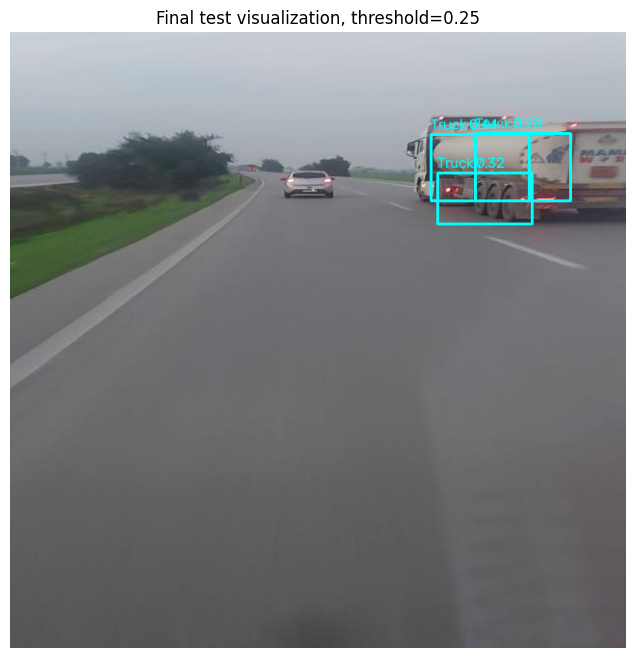

FINAL TEST 절차 완료. 이 결과로 모델/threshold를 다시 선택하지 마세요.


In [30]:
# [필수 실행, 마지막 절차] 이 셀에서만 수정
RUN_FINAL_TEST = True
ALLOW_REPEAT_FINAL_TEST = False
TEST_ATTEMPT = 'test_final_01'

TEST_PROJECT = f'{PROJECT_NAME}_test'
TEST_YAML = REPO_DIR/'projects'/f'{TEST_PROJECT}.yml'
test_cfg = dict(project_cfg)
test_cfg['val_set'] = 'test'
TEST_YAML.write_text(yaml.safe_dump(test_cfg, sort_keys=False, allow_unicode=True), encoding='utf-8')
FINAL_TEST_MARKER = LOCAL_RUN_DIR/'FINAL_TEST_COMPLETED.json'
DRIVE_TEST_MARKER = DRIVE_RESULT_DIR/'FINAL_TEST_COMPLETED.json'
TEST_OUTPUT_DIR = LOCAL_RUN_DIR/'coco_eval'/TEST_ATTEMPT

if RUN_FINAL_TEST:
    if (FINAL_TEST_MARKER.exists() or DRIVE_TEST_MARKER.exists()) and not ALLOW_REPEAT_FINAL_TEST:
        raise RuntimeError(f'동일 RUN_ID의 final test 완료 marker가 있습니다: {FINAL_TEST_MARKER}')
    assert SELECTED_CKPT is not None, 'validation으로 선택한 checkpoint가 필요합니다.'
    assert VAL_CACHE is not None, '먼저 validation 비교를 실행하세요.'
    assert 'threshold_rows' in globals() and threshold_rows, 'validation threshold 결과가 필요합니다.'
    chosen_threshold = max(threshold_rows, key=lambda x:x['f1'])['threshold']
    assert not TEST_OUTPUT_DIR.exists(), f'기존 test attempt와 섞지 않습니다: {TEST_OUTPUT_DIR}'
    TEST_OUTPUT_DIR.mkdir(parents=True)

    run_cmd_logged([sys.executable,'coco_eval.py','-c','0','-p',TEST_PROJECT,
             '-w',SELECTED_CKPT,'--cuda',str(torch.cuda.is_available()),'--override','True',
             '--output_dir',TEST_OUTPUT_DIR,'--metrics_dir',TEST_OUTPUT_DIR],
             TEST_OUTPUT_DIR/'stdout.log')

    # COCO test 수치가 공개된 즉시 marker를 먼저 남깁니다. 이후 시각화가 실패해도 재평가를 막습니다.
    marker = json.loads(FINAL_TEST_MARKER.read_text(encoding='utf-8')) if FINAL_TEST_MARKER.exists() else {'runs':[]}
    run_entry = {
        'completed_at': datetime.now(timezone.utc).astimezone().isoformat(),
        'attempt': TEST_ATTEMPT,
        'checkpoint': str(Path(SELECTED_CKPT).resolve()),
        'checkpoint_sha256': sha256_file(SELECTED_CKPT),
        'threshold': float(chosen_threshold),
        'repeat_override': bool(ALLOW_REPEAT_FINAL_TEST),
        'status': 'coco_eval_completed_visualization_pending',
    }
    marker['runs'].append(run_entry)
    FINAL_TEST_MARKER.write_text(json.dumps(marker, indent=2, ensure_ascii=False), encoding='utf-8')
    if SAVE_TO_DRIVE: sync_file(FINAL_TEST_MARKER, DRIVE_TEST_MARKER)

    test_cache = cache_predictions(custom_model, 'test', 1)
    item = test_cache[0]; keep=item['scores']>=chosen_threshold
    pred={'rois':item['pred_boxes'][keep], 'class_ids':item['pred_cls'][keep]-1, 'scores':item['scores'][keep]}
    test_render = draw_prediction(item['rgb'], pred, OBJ_LIST)
    Image.fromarray(test_render).save(TEST_OUTPUT_DIR/'test_final_visualization.png')
    plt.figure(figsize=(12,8)); plt.imshow(test_render); plt.axis('off')
    plt.title(f'Final test visualization, threshold={chosen_threshold}'); plt.show()

    run_entry['status'] = 'complete'
    FINAL_TEST_MARKER.write_text(json.dumps(marker, indent=2, ensure_ascii=False), encoding='utf-8')
    if SAVE_TO_DRIVE: sync_file(FINAL_TEST_MARKER, DRIVE_TEST_MARKER)
    print('FINAL TEST 절차 완료. 이 결과로 모델/threshold를 다시 선택하지 마세요.')
else:
    print('SKIP_INCOMPLETE: RUN_FINAL_TEST=False. test 최종 절차는 아직 실행하지 않았습니다.')

## 12. 결과 해석과 회고

### 1) 실험 조건과 진행 범위

EfficientDet-D0를 사용해 사전학습 추론, 데이터 검증, 미세조정, 최종 평가까지 진행했습니다. 실행일은 2026년 9월 27일이며, RUN_ID는 `20260927_083522`입니다.

| 항목 | 실제 실행 조건 |
|---|---|
| 환경 | Colab T4, CUDA 사용 |
| 데이터 | Kaggle Vehicle Detection Image Dataset v7의 `Apply_Grayscale` 아래 COCO 데이터 |
| 분리 | train 136장 / validation 28장 / test 13장 |
| 입력·학습 | 512×512, batch 16, 초기 learning rate 0.001 |
| 학습 단계 | head-only 10 epoch + 전체 모델 30 epoch |
| 모델 선택 | full 단계 validation total loss가 가장 낮은 checkpoint |
| 비교 조건 | 동일 checkpoint·validation 28장, confidence 0.25 / 0.50 / 0.75 |
| 최종 test | 13장에 대해 1회 평가, 이후 설정 변경이나 재학습 없음 |

두 학습 단계 모두 batch 16으로 완료됐고, CUDA OOM에 따른 batch 8 재시도는 발생하지 않았습니다. 코드 호환성 수정과 실행·결과 정리에는 AI 도구의 도움을 받았습니다. 아래 수치는 노트북의 실제 출력에 근거하며, 수행하지 않은 실험은 별도로 구분했습니다.

### 2) 사전학습 이미지와 영상 추론

저장소의 예제 이미지에서 confidence 0.25 기준으로 객체 25개가 탐지됐습니다. 화면에서 승용차와 버스 등의 박스를 확인할 수 있었지만, 이 이미지에 정답 라벨을 대조한 것은 아니므로 탐지 개수만으로 정확도를 판단하지 않았습니다.

교안의 축구 영상 대신 Kaggle 데이터에 포함된 `SampleVideo_LowQuality.mp4`를 사용했습니다. 앞 300프레임을 처리해 MP4로 저장했고, 첫·중간·마지막 처리 프레임도 아래에 남겼습니다. 원본 FPS 24 기준으로 약 12.5초 분량입니다. 여기서 24 FPS는 영상의 재생 정보이지 모델의 처리 속도를 측정한 값이 아닙니다. 또한 이 영상 결과는 **COCO 사전학습 모델의 결과**이며, 차량 데이터로 미세조정한 모델의 영상 성능과 혼동하지 않았습니다.

### 3) 데이터 품질과 클래스 분포

세 split의 파일·박스 검증 오류는 모두 0개였습니다. 원본은 수정하지 않았으며, 작업 복사본에서 category ID와 annotation ID만 연속된 양수로 다시 매겼습니다. 파일명과 SHA-256이 일치하는 split 간 중복도 없었습니다. 다만 이것만으로 비슷한 장면이나 인접 영상 프레임까지 완전히 분리됐다고 보장할 수는 없습니다.

학습 정답 2,724개 중 `Car`가 2,023개로 약 74.3%를 차지했습니다. 나머지는 Bus 31개, Motorcycle 355개, Pickup 251개, Truck 64개였습니다. `cars`라는 별도 category에는 정답이 없었지만, 원본 정의를 임의로 바꾸지 않기 위해 유지했습니다. 따라서 **category 정의는 6개이지만 실제 정답이 있는 클래스는 5개**입니다.

### 4) 정규화와 anchor 통계

평가 데이터가 학습 설정에 섞이지 않도록 mean/std와 anchor 통계는 train 136장에서만 구했습니다.

- RGB mean: `[0.464601, 0.470941, 0.469176]`
- RGB std: `[0.167243, 0.166229, 0.166747]`
- 512 입력으로 환산한 박스 크기의 중앙값: 약 **13.99픽셀** (`sqrt(width×height)` 기준)
- 사용한 anchor scales: `[0.24, 0.437, 0.813]`
- 사용한 anchor ratios: `[(0.724, 1.382), (0.816, 1.225), (0.910, 1.099)]`

작은 객체를 고려해 train 통계 기반 anchor를 사용했지만, 기본 COCO anchor와의 비교 실험은 하지 않았습니다. 따라서 이번 결과만으로 anchor 변경이 성능을 높였다고 결론 내릴 수는 없습니다. 폴더 이름에 Grayscale이 있더라도 실제 RGB 통계가 완전히 같지는 않았으므로 모든 이미지가 순수한 회색조라고 단정하지 않았습니다.

### 5) 학습 결과와 모델 선택

| 단계 | 첫 epoch validation loss | 최저 validation loss | 선택된 epoch |
|---|---:|---:|---:|
| Head-only | 16200.6451 | 143.5595 | 10 / 10 |
| Full fine-tuning | 14.8410 | 2.2852 | 30 / 30 |

표의 epoch는 1부터 센 값이며, 로그에서는 0부터 표시됩니다. 최종 가중치는 `efficientdet-d0_29_240.pth`입니다. validation 28장 전체를 확인하도록 마지막 미완성 배치도 평가에 포함했습니다.

loss는 크게 감소했지만, 이것을 곧바로 높은 탐지 성능으로 해석하지 않았습니다. head-only 모델에 대한 별도 AP 평가나 사전학습 모델과의 동일 조건 AP 비교는 하지 않았으므로, loss 변화 외에 각 단계의 정확도 향상 폭은 제시하지 않았습니다.

### 6) Confidence 비교와 선택 이유

같은 validation 28장, 같은 모델에서 클래스가 같고 IoU가 0.5 이상인 예측을 1:1로 연결해 계산했습니다. Precision·Recall·F1은 모든 클래스의 TP/FP/FN을 합친 값입니다.

| Confidence | TP | FP | FN | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| 0.25 | 181 | 313 | 382 | 0.3664 | 0.3215 | **0.3425** |
| 0.50 | 45 | 3 | 518 | **0.9375** | 0.0799 | 0.1473 |
| 0.75 | 0 | 0 | 563 | 0.0000* | 0.0000 | 0.0000 |

*0.75에서는 예측 자체가 없어 Precision을 통상적인 의미로 평가할 수 없습니다. 표의 0은 코드의 분모 0 처리 규칙입니다.*

0.50에서는 오탐이 줄었지만 정답 563개 중 45개만 찾았습니다. 그래서 Precision만 보고 0.50이 가장 좋다고 판단하지 않았습니다. 이번 실습에서는 비교한 세 조건 중 F1이 가장 높은 **0.25**를 최종 시각화 기준으로 선택했습니다. 이는 전체 confidence 범위에서의 최적값을 찾았다는 의미는 아닙니다.

같은 validation 예시 이미지에서도 0.25에서는 차량뿐 아니라 넓은 배경 영역에 큰 박스가 나타났습니다. 0.50에서는 표시되는 차량이 줄었고, 0.75에서는 박스가 사라졌습니다. 이는 표에서 확인한 오탐·미탐의 교환 관계를 보여 주지만, 한 장의 예시를 전체 데이터의 성능으로 일반화하지는 않았습니다.

선택한 0.25에서도 TP 181개 중 179개가 Car였습니다. Bus와 Motorcycle은 TP가 0개였고, Pickup과 Truck은 각각 1개였습니다. 따라서 차량 종류를 균형 있게 구분하는 모델이라고 보기는 어렵습니다.

### 7) 최종 COCO 평가와 한계

| 데이터 | 이미지 수 | mAP50–95 | mAP50 | mAP75 | AR100 |
|---|---:|---:|---:|---:|---:|
| Validation | 28 | 0.0543 | 0.0861 | 0.0626 | 0.1686 |
| Test | 13 | 0.0576 | 0.0889 | 0.0663 | 0.1278 |

AP는 confidence 한 지점의 Precision과 다른 지표이며, 클래스별 정밀도·재현율 곡선을 요약합니다. COCO 평가는 저장소의 score floor 0.05와 NMS IoU 0.5 설정을 사용했습니다. 선택한 confidence 0.25는 위의 validation 비교 및 최종 이미지 시각화에 적용한 값입니다. AR100은 IoU 0.50~0.95에서 이미지·클래스당 최대 100개 탐지를 고려한 평균 Recall이므로, 앞 표의 IoU 0.5 기준 Recall과 그대로 비교하면 안 됩니다.

테스트 mAP50–95는 약 5.76%로 낮았습니다. 작은 객체의 AP도 validation 0.0430, test 0.0405에 그쳤습니다. 데이터의 작은 객체 비중, 클래스 불균형, 학습 조건 등이 가능한 원인이지만, 원인별 비교 실험을 하지 않았으므로 어느 한 가지가 원인이라고 확정하지 않았습니다. 특히 validation 28장과 test 13장은 작고 같은 데이터 출처이므로, 두 점수가 비슷하다고 해서 일반화가 검증됐다고 보지는 않았습니다.

최종 test 예시에서는 오른쪽 대형 차량 주변에 여러 박스가 겹치고, 앞쪽 승용차 일부에는 박스가 표시되지 않았습니다. 따라서 수치뿐 아니라 화면에서도 박스 위치와 미탐을 개선할 필요가 있었습니다.

이번 결과는 실행과 평가 절차를 확인한 실습 결과이지, 실제 제조·교통 현장에 바로 적용할 수준의 모델은 아닙니다. Test를 확인한 뒤 점수를 높이려고 설정을 바꾸거나 다시 학습하지 않았습니다.

### KPT

**Keep**
- 학습 전에 라벨, 이미지 파일, 클래스 구성과 split 중복을 확인한 과정을 유지하겠습니다. 데이터 문제와 모델 문제를 구분하는 데 도움이 됐습니다.
- 같은 모델과 검증 데이터로 confidence만 바꾼 비교를 유지하겠습니다. Precision 하나만 보면 놓칠 수 있는 미탐 문제를 확인할 수 있었습니다.
- 실행 조건, 원본 코드 commit, 실제 지표와 최적 가중치를 함께 보관하겠습니다. 결과를 다시 확인할 근거가 남았습니다.

**Problem**
- loss 감소에 비해 AP가 낮았고, 탐지 결과가 Car에 치우쳤습니다. 전체 학습이 끝났다는 사실과 모델이 잘 동작한다는 판단을 구분해야 했습니다.
- confidence 0.25에서는 오탐 313개, 0.50에서는 미탐 518개가 발생했습니다. threshold 조절만으로 현재 모델의 한계를 해결하기는 어려웠습니다.
- anchor·입력 크기·학습 시간의 효과를 각각 분리한 비교가 부족했습니다. 영상 처리 속도나 미세조정 후 영상 성능도 측정하지 않았습니다.

**Try: 다음 실험에서 실행할 항목**
1. **기본 anchor와 통계 기반 anchor 비교:** 동일 split·seed·학습 epoch를 유지하고 anchor만 바꿔 validation mAP50–95, AP-small, 클래스별 Recall을 표로 비교하겠습니다. 실제 효과가 있었는지 확인하기 위해서입니다.
2. **실패 사례 점검:** validation에서 Bus·Motorcycle 미탐과 Pickup·Truck 오탐을 각 최대 10건씩 뽑아 클래스 혼동, 작은 크기, 가림, 라벨 문제로 분류하겠습니다. 그 결과를 보고 부족한 클래스의 데이터 보강이나 sampling을 결정하겠습니다.
3. **작은 객체와 재현성 확인:** 입력 512와 더 큰 입력을 같은 조건에서 비교하고, VRAM·추론시간·AP-small을 함께 기록하겠습니다. 유망한 설정은 seed 3개로 반복해 평균과 변동을 확인하겠습니다. 이 항목들은 아직 수행하지 않은 후속 계획입니다.

이미 공개한 test 결과로 후속 실험을 반복 선택하지 않고, 다음 모델 선택에는 validation을 사용하겠습니다. 최종 일반화 확인에는 새로 분리한 holdout 데이터가 필요합니다.


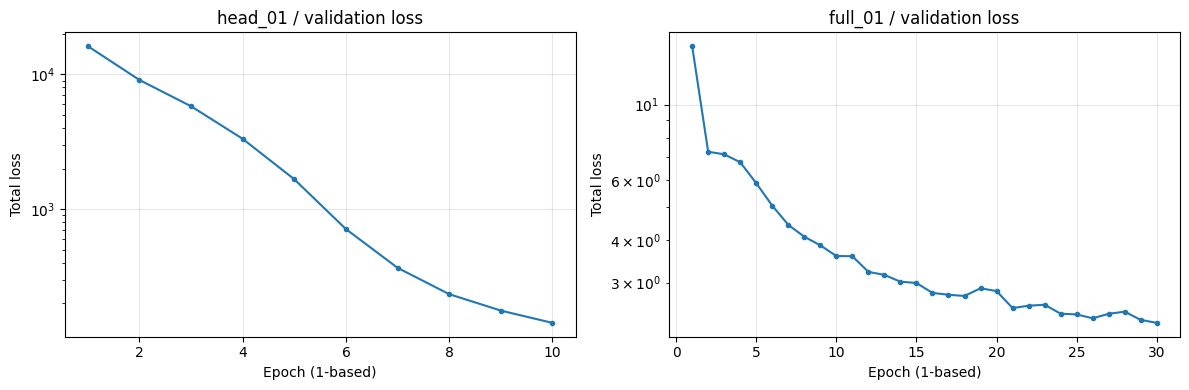

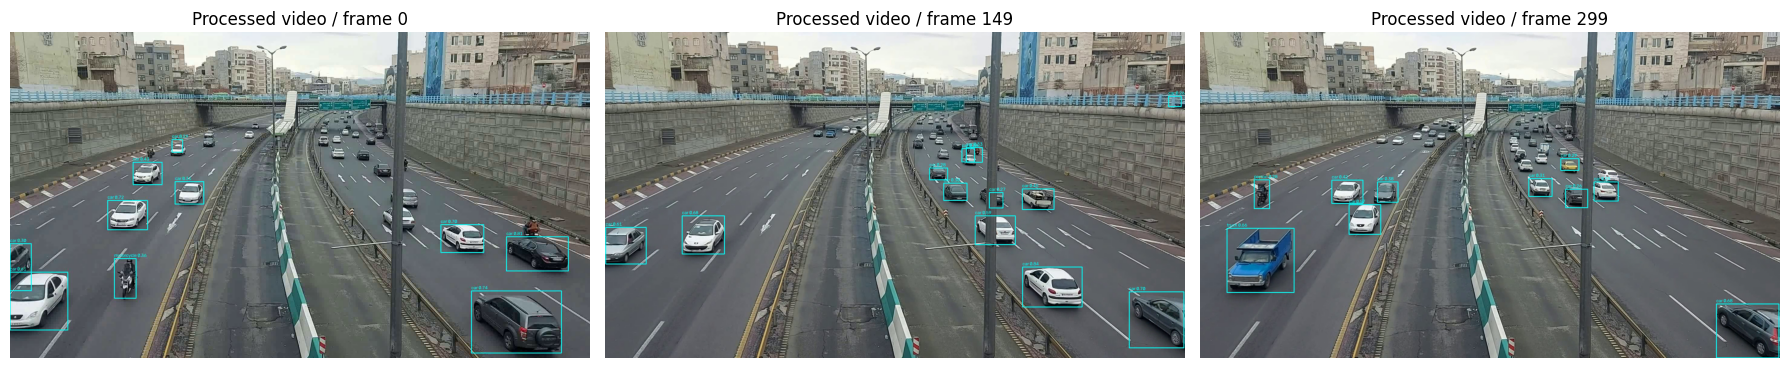

실행 결과 요약(JSON):
{
  "run_id": "20260927_083522",
  "epochs_completed": {
    "head_01": 10,
    "full_01": 30
  },
  "validation_loss": {
    "head_01": {
      "first": 16200.645123958588,
      "last": 143.55946099758148,
      "best": {
        "epoch": 9,
        "step": 80,
        "classification_loss": 140.9075050354004,
        "regression_loss": 2.6519559621810913,
        "total_loss": 143.55946099758148,
        "is_best": true,
        "checkpoint_path": "/content/effdet_runs/20260927_083522/training/head_01/checkpoints/vehicle_detection_20260927_083522/efficientdet-d0_9_80.pth"
      }
    },
    "full_01": {
      "first": 14.841042280197144,
      "last": 2.28519606590271,
      "best": {
        "epoch": 29,
        "step": 240,
        "classification_loss": 0.5994969010353088,
        "regression_loss": 1.6856991648674011,
        "total_loss": 2.28519606590271,
        "is_best": true,
        "checkpoint_path": "/content/effdet_runs/20260927_083522/training/full_01/

In [32]:
# 실제 실행 기록만 사용해 결과를 정리합니다. 추가 학습이나 test 재평가는 하지 않습니다.
validation_metrics = json.loads((val_eval_dir/'valid_coco_metrics.json').read_text())
test_metrics = json.loads((TEST_OUTPUT_DIR/'test_coco_metrics.json').read_text())

stage_histories = {}
for stage in (HEAD_ATTEMPT, FULL_ATTEMPT):
    history_paths = list((LOCAL_RUN_DIR/'training'/stage).rglob('validation_metrics.jsonl'))
    assert len(history_paths) == 1, history_paths
    stage_histories[stage] = [json.loads(line) for line in history_paths[0].read_text().splitlines() if line.strip()]
assert len(stage_histories[HEAD_ATTEMPT]) == HEAD_EPOCHS
assert len(stage_histories[FULL_ATTEMPT]) == FULL_EPOCHS

# 검증 데이터의 클래스별 결과입니다. 정답이 없는 클래스의 Recall은 계산하지 않습니다.
class_rows = []
for category_id, class_name in enumerate(OBJ_LIST, start=1):
    tp = fp = fn = 0
    for item in VAL_CACHE:
        gm = item['gt_cls'] == category_id
        pm = (item['pred_cls'] == category_id) & (item['scores'] >= chosen_threshold)
        a, b, c = greedy_counts(item['gt_boxes'][gm], item['gt_cls'][gm],
                               item['pred_boxes'][pm], item['pred_cls'][pm], item['scores'][pm], IOU_MATCH)
        tp += a; fp += b; fn += c
    class_rows.append({'class': class_name, 'gt_count': tp+fn, 'tp': tp, 'fp': fp, 'fn': fn,
                       'precision': tp/(tp+fp) if tp+fp else None,
                       'recall': tp/(tp+fn) if tp+fn else None})

result_summary = {
    'run_id': RUN_ID,
    'epochs_completed': {k: len(v) for k,v in stage_histories.items()},
    'validation_loss': {k: {'first': v[0]['total_loss'], 'last': v[-1]['total_loss'],
                            'best': min(v, key=lambda r:r['total_loss'])} for k,v in stage_histories.items()},
    'validation_metrics': validation_metrics,
    'test_metrics': test_metrics,
    'threshold_comparison': threshold_rows,
    'chosen_confidence': float(chosen_threshold),
    'validation_per_class': class_rows,
    'train_mean': TRAIN_MEAN.tolist(), 'train_std': TRAIN_STD.tolist(),
    'video': video_status,
    'test_runs': len(json.loads(FINAL_TEST_MARKER.read_text())['runs']),
}
write_json_atomic(LOCAL_RUN_DIR/'final_result_summary.json', result_summary)
with (LOCAL_RUN_DIR/'validation_per_class.csv').open('w', newline='', encoding='utf-8') as f:
    cw = csv.DictWriter(f, fieldnames=class_rows[0].keys()); cw.writeheader(); cw.writerows(class_rows)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, (stage, history) in zip(axes, stage_histories.items()):
    ax.plot([r['epoch']+1 for r in history], [r['total_loss'] for r in history], marker='o', markersize=3)
    ax.set_title(stage+' / validation loss'); ax.set_xlabel('Epoch (1-based)'); ax.set_ylabel('Total loss')
    ax.set_yscale('log'); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(LOCAL_RUN_DIR/'validation_loss_curves.png', dpi=150); plt.show()

# 이미 처리한 영상의 첫·중간·마지막 프레임을 확인합니다. 영상 추론은 다시 하지 않습니다.
if video_status.get('status') == 'DONE':
    cap = cv2.VideoCapture(video_status['output'])
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fig, axes = plt.subplots(1,3,figsize=(18,6))
    for ax, frame_index in zip(axes, [0, max(0,frame_count//2-1), max(0,frame_count-1)]):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
        ok, frame = cap.read()
        if ok: ax.imshow(cv2.cvtColor(frame,cv2.COLOR_BGR2RGB))
        ax.set_title(f'Processed video / frame {frame_index}'); ax.axis('off')
    cap.release(); fig.tight_layout()
    fig.savefig(LOCAL_RUN_DIR/'video_preview_frames.png',dpi=150); plt.show()

print('실행 결과 요약(JSON):')
print(json.dumps(result_summary, ensure_ascii=False, indent=2))

# [필수 실행] 실행 산출물 manifest와 Drive RUN_ID 폴더 동기화 (재실행 가능, 바뀐 파일만 교체)
manifest = {
    'run_id': RUN_ID,
    'repo_commit': actual_commit,
    'source_colab': 'https://colab.research.google.com/drive/1IEaZ030mPBNJzez6RZvUkmAZe-A2lrhP',
    'dataset_source': str(SOURCE_ROOT),
    'working_dataset': str(WORK_DATASET),
    'classes': OBJ_LIST,
    'zero_train_categories_kept': globals().get('ZERO_TRAIN_CATEGORIES'),
    'conversion_stats': globals().get('conversion_stats'),
    'anchor_mode': globals().get('ANCHOR_MODE'),
    'anchor_ablation_performed': False,
    'run_head_train': globals().get('RUN_HEAD_TRAIN', False),
    'run_full_train': globals().get('RUN_FULL_TRAIN', False),
    'head_stage_summary': globals().get('HEAD_SUMMARY'),
    'full_stage_summary': globals().get('FULL_SUMMARY'),
    'run_val_coco_eval': globals().get('RUN_VAL_COCO_EVAL', False),
    'run_final_test': globals().get('RUN_FINAL_TEST', False),
    'selected_checkpoint': str(SELECTED_CKPT) if SELECTED_CKPT else None,
    'selected_checkpoint_sha256': sha256_file(SELECTED_CKPT) if SELECTED_CKPT else None,
    'checkpoint_drive_backup': str(checkpoint_backup) if globals().get('checkpoint_backup') else None,
    'video_status': video_status,
    'final_test_marker': str(FINAL_TEST_MARKER) if FINAL_TEST_MARKER.exists() else None,
    'note': 'test is a final procedure; repeat requires explicit override; no score guarantee',
}
write_json_atomic(LOCAL_RUN_DIR/'run_manifest.json', manifest)

if SAVE_TO_DRIVE:
    allowed = {'.csv','.png','.jpg','.mp4','.json','.jsonl','.yml','.yaml','.txt','.log'}
    sync_counts = Counter()
    for artifact in sorted(LOCAL_RUN_DIR.rglob('*')):
        if artifact.is_file() and artifact.suffix.lower() in allowed and not artifact.name.startswith('.'):
            rel = artifact.relative_to(LOCAL_RUN_DIR)
            sync_counts[sync_file(artifact, DRIVE_RESULT_DIR/rel)] += 1
    # checkpoint는 학습 stage/9절에서 stage best만 보관합니다. 여기서 추가 복사하지 않습니다.
    print('Drive 동기화 결과:', dict(sync_counts))
    print('Drive 결과 폴더:', DRIVE_RESULT_DIR)
else:
    print('Drive 저장 비활성화. 로컬 결과:', LOCAL_RUN_DIR)

print('완료 항목은 manifest, validation JSONL/CSV, COCO metric JSON/CSV, stdout log를 확인하세요.')
print('SKIP_INCOMPLETE 항목은 제출 전 직접 완료해야 합니다.')

## 코드 변경 메모

- 1절: NumPy·PyTorch 호환성, 제한된 checkpoint 로드, validation JSONL·COCO JSON/CSV 저장을 보완했습니다.
- 1절: validation loader의 `drop_last=False`로 마지막 12장을 버리지 않고 28장 전체를 평가했습니다.
- 2·4절: 실제 Kaggle 데이터 및 포함 영상 경로를 지정했습니다. 교안 영상과 다르다는 점을 기록했습니다.
- 5·6절: 파일·박스 검증과 중복 점검을 추가하고, 원본을 보존한 작업본에서 ID만 변환했습니다.
- 9절: 실행별 폴더, validation 기반 checkpoint 선택, 단계별 Drive 백업, OOM 감지·제한된 재시도를 추가했습니다. 이번에는 OOM 재시도를 사용하지 않았습니다.
- 10·11절: 같은 validation 예측으로 confidence를 비교하고, test 완료 marker를 로컬과 Drive에 보관했습니다.
- 12절: 실측 결과·해석·KPT, validation loss 곡선, 클래스별 TP/FP/FN, 이미 처리한 영상의 대표 프레임을 추가했습니다.

학습 재실행 없이 저장된 출력과 수치만으로 회고를 작성했습니다. 추가 anchor 비교·더 큰 입력 실험·seed 반복은 후속 계획이며 완료한 것으로 기재하지 않았습니다.